<a href="https://colab.research.google.com/github/AminaSagymbayeva/Fire_Model_Analysis/blob/main/Fire_Model_Assessment_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Please define the path to your NetCDF files (observed and model data)
observed_netcdf_path = ''
model_netcdf_path = ''

# Define the path to the US GACC fire regions mask shapefile
us_gacc_path = "/GACC_shapefiles/National_GACC_Boundaries.shp"

# Define the variables of interest (e.g. burned area)
observed_var = ''
model_var = ''

# Define the time period for figure titles
start_year =
end_year =

# Define a scale factor (for the colorbars)
scale_factor =
units_scaled = 'Thousand km²'

# Define thw path for output figures
output_path = ''

# Loading data
This workflow is compatible with NetCDF files containing ensemble fire simulation model outputs in a single file. Each file should contain at least burned area variable and three coordinates: time, latitude, and longitude. **Please ensure that the spatial grid of observed and model NetCDF files match.**

NetCDF format requirements:

1. Latitude range [-90, 90] # can be adjusted
2. Longitude range [-180, 180] # can be adjusted
3. Variable of interest should have NA values over water bodies, such as seas, lakes, and oceans.
4. Coordinates should be named 'latitude', 'longitude', and 'time'

**IMPORTANT**: Choose either Global Map or US Map subsection to complete the analysis for the appropriate region. Coordinates can be adjusted in case a different region is to be analyzed.

In [1]:
!pip install cartopy regionmask
import xarray as xr
import numpy as np
import pandas as pd
from math import nan
import scipy.stats as stats
import plotly.express as px
import seaborn as sns
import geopandas as gp
import regionmask
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from xarray.groupers import SeasonResampler, SeasonGrouper
from scipy.stats import pearsonr, spearmanr
from matplotlib.gridspec import GridSpec
from scipy.spatial import distance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Loading simulated data aggregated along time axis
model_agg = xr.open_dataset(model_netcdf_path)
# model_agg

In [ ]:
# Loading observed data aggregated along time axis
observed_agg = xr.open_dataset(observed_netcdf_path)
observed_agg = observed_agg.where(model_agg[model_var].notnull()) # optional: assigns NA value to the variable of interest over water bodies

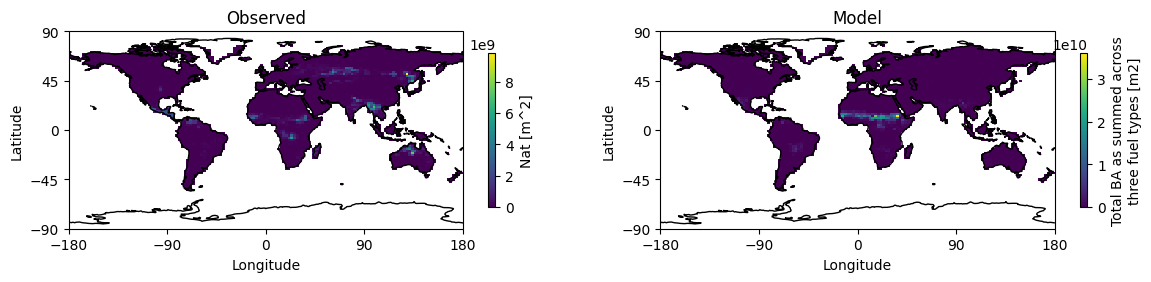

In [ ]:
# Inspect the loaded NetCDF files for inconsistencies
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

observed_agg.isel(time=15)[observed_var].plot(ax=ax[0], cbar_kwargs={'shrink': 0.2, 'orientation': 'vertical'}, cmap='viridis')
ax[0].coastlines()
ax[0].set_title('Observed')

model_agg.isel(time=15)[model_var].plot(ax=ax[1], cbar_kwargs={'shrink': 0.2, 'orientation': 'vertical'}, cmap='viridis')
ax[1].coastlines()
ax[1].set_title('Model')

for a in ax:
  a.set_xticks(range(-180, 181, 90), crs=ccrs.PlateCarree())
  a.set_yticks(range(-90, 91, 45), crs=ccrs.PlateCarree())
  a.set_xlabel('Longitude')
  a.set_ylabel('Latitude')

In [ ]:
def crop_to_region(data, lat, lon, lat_borders, lon_borders):
  '''cropping the dataset to the mainland US. Note: border coordinates can be adjusted as needed'''
  data = data.where((data[lat] >= lat_borders[0])&(data[lat] <= lat_borders[1])&(data[lon] >= lon_borders[0])
                    &(data[lon] <= lon_borders[1]), drop = True)
  return data

# Global Map

In [ ]:
# Define geographical boundary coordinates
lat_borders, lon_borders = [-90, 90], [-180, 180] # global
lat_borders_maps, lon_borders_maps = [-90, 90, 50], [-180, 180, 50] # global (drawing map frame)
model = crop_to_region(model_agg, 'latitude', 'longitude', lat_borders, lon_borders)
observed = crop_to_region(observed_agg, 'latitude', 'longitude', lat_borders, lon_borders)

Text(0, 0.5, 'Latitude')

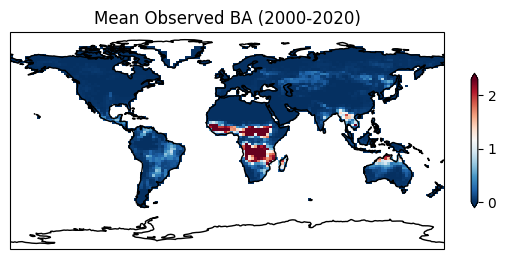

In [ ]:
# Reference figure
observed_mean = observed.mean(dim='time', skipna=True)/scale_factor

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': ccrs.PlateCarree()})
observed_mean[observed_var].plot(ax=ax, cmap='RdBu_r', robust=True,
          cbar_kwargs={'shrink': 0.25, 'orientation': 'vertical', 'extend': 'both', 'label': ''})
ax.set_title(f'Mean Observed BA ({start_year}-{end_year})')
ax.coastlines()
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# US Map

In [ ]:
# Loading shapefile with US fire regions
usgacc = gp.read_file(us_gacc_path).reset_index(drop=True)[['GACCAbbrev', 'geometry']]
usgacc = usgacc.to_crs("EPSG:4326")

# Merging all subregions with the same abbreviation
regions_merged = usgacc.dissolve(by='GACCAbbrev', as_index=False)

# Creating fire regions 2D mask from shapefile
fireregions_mask = regionmask.mask_geopandas(regions_merged, observed_agg.longitude, observed_agg.latitude)

# Cropping fire regions to the US area
lat_borders, lon_borders = [24.5, 80], [-180, -66.9]  # for mainland US
lat_borders_maps, lon_borders_maps = [20, 80, 10], [-180, -50, 10] # for mainland US (drawing map frame)
fireregions_mask_US = crop_to_region(fireregions_mask, 'latitude', 'longitude', lat_borders, lon_borders)
observed = observed_agg[observed_var].where(fireregions_mask_US.notnull()).to_dataset(name=observed_var)
model = model_agg[model_var].where(fireregions_mask_US.notnull()).to_dataset(name=model_var)
# observed

Text(0, 0.5, 'Latitude')

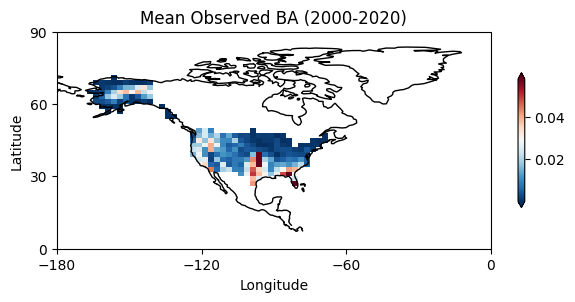

In [ ]:
# Reference figure
observed_US_mean = observed.mean(dim='time', skipna=True)/scale_factor

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': ccrs.PlateCarree()})
observed_US_mean[observed_var].plot(ax=ax, cmap='RdBu_r', robust=True,
          cbar_kwargs={'shrink': 0.25, 'orientation': 'vertical', 'extend': 'both', 'label': ''})
ax.set_title(f'Mean Observed BA ({start_year}-{end_year})')
ax.coastlines()
ax.set_xticks(range(-180, 10, 60), crs=ccrs.PlateCarree())
ax.set_yticks(range(0, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Time trends


*   Mean Burned Area (+ by season)
*   Time Series of Monthly  Burned Area
*   Time Series of Burned Area by season



In [ ]:
# Calculating seasonal means
observed_seasonal_mean = observed[observed_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).mean(skipna=True)
observed_seasonal_std = observed[observed_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).std(skipna=True)

model_seasonal_mean = model[model_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).mean(skipna=True)
model_seasonal_std = model[model_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).std(skipna=True)

# Bringing to the pre-defined scale
model_seasonal_mean = model_seasonal_mean/scale_factor
observed_seasonal_mean = observed_seasonal_mean/scale_factor
observed_seasonal_std = observed_seasonal_std/scale_factor
model_seasonal_std = model_seasonal_std/scale_factor

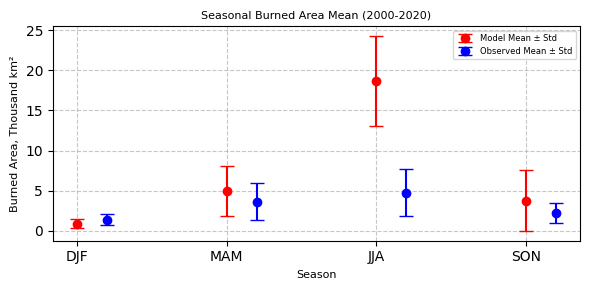

In [ ]:
x_labels = observed_seasonal_mean.season.values
x_model_positions = np.arange(len(x_labels))-0.1
x_obs_positions = np.arange(len(x_labels))+0.1

Figure = plt.figure(figsize=(6, 3))

plt.errorbar(x_model_positions, model_seasonal_mean.values, yerr=model_seasonal_std.values,
             fmt='ro', capsize=5, label='Model Mean ± Std')

plt.errorbar(x_obs_positions, observed_seasonal_mean.values, yerr=observed_seasonal_std.values,
             fmt='bo', capsize=5, label='Observed Mean ± Std')

plt.xticks(x_model_positions, x_labels)
plt.xlabel('Season', fontsize=8)
plt.ylabel(f'Burned Area, {units_scaled}', fontsize=8)
plt.title(f'Seasonal Burned Area Mean ({start_year}-{end_year})', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=6)
plt.tight_layout()
plt.savefig(f'{output_path}/seasonal_means_boxplot.tiff')

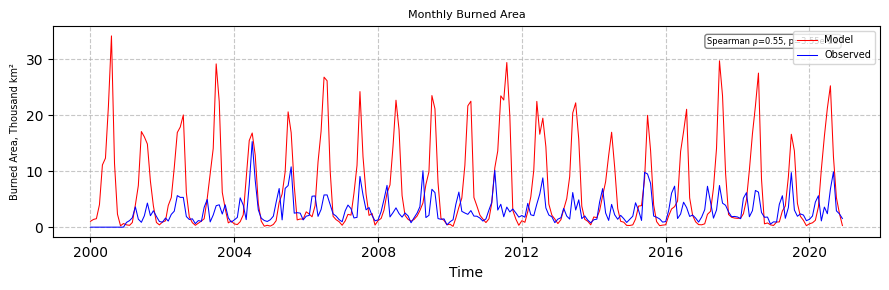

In [ ]:
observed_sum = observed[observed_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor
model_sum = model[model_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor
r, p = spearmanr(observed_sum, model_sum)

fig, ax = plt.subplots(figsize=(9, 3))

model_sum.plot(ax=ax, label='Model', linestyle='-', color='red', linewidth=0.75)
observed_sum.plot(ax=ax, label='Observed', linestyle='-', color='blue', linewidth=0.75)
ax.set_xlabel('Time')
ax.set_ylabel(f'Burned Area, {units_scaled}', fontsize=7)
ax.set_title('Monthly Burned Area', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=7)
ax.text(x=0.95, y=0.95, s=f'Spearman ρ={r:.2f}, p={p:.2e}', transform=ax.transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top', fontsize=6)

plt.tight_layout()
plt.savefig(f'{output_path}/monthly_time_series.tiff')

In [ ]:
model_seasonal_sum = model[model_var].sum(dim=['latitude', 'longitude'],skipna=True).groupby(time=SeasonResampler(["DJF", "MAM", "JJA", "SON"],
                                                  drop_incomplete=True)).sum()/scale_factor
observed_seasonal_sum = observed[observed_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonResampler(["DJF", "MAM", "JJA", "SON"],
                                                  drop_incomplete=True)).sum()/scale_factor

seasons = model_seasonal_sum.time.dt.season
model_seasonal_sum = model_seasonal_sum.assign_coords(season=seasons)
observed_seasonal_sum = observed_seasonal_sum.assign_coords(season=seasons)

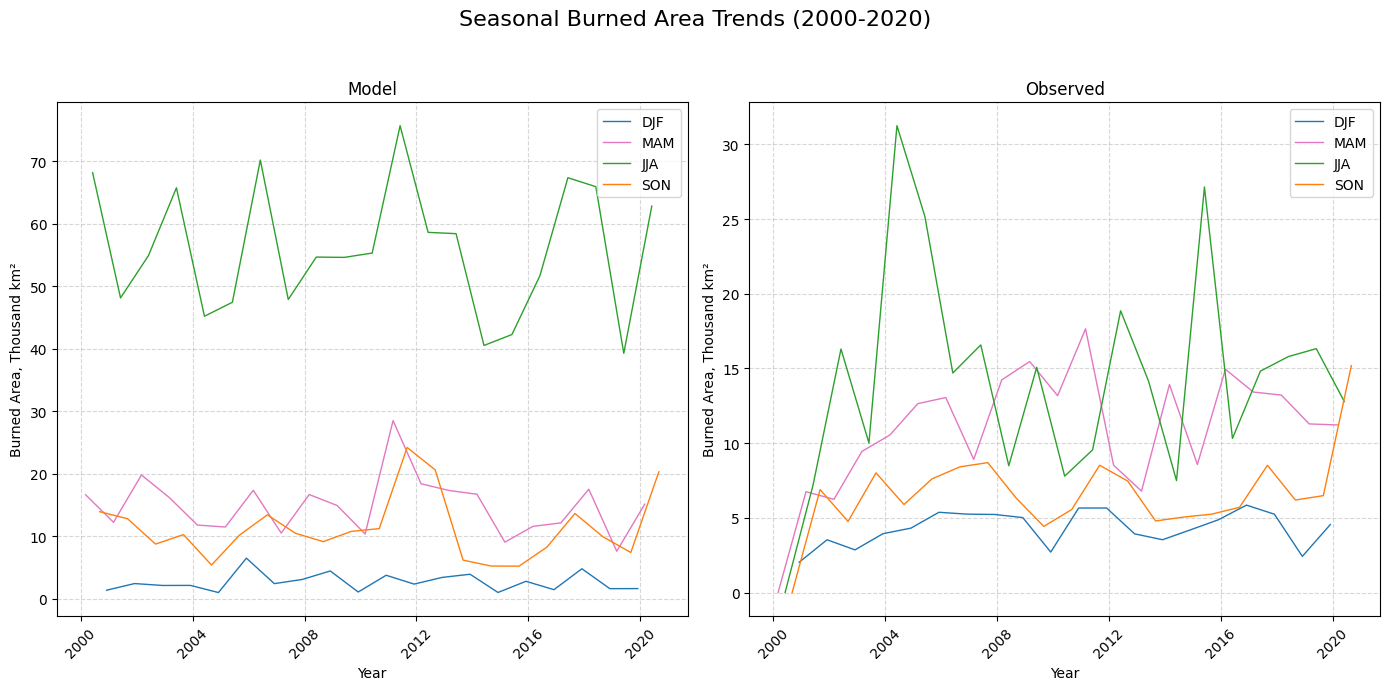

In [ ]:
# Suitable for US analysis
fig, ax = plt.subplots(figsize=(14, 7), nrows=1, ncols=2)
fig.suptitle(f'Seasonal Burned Area Trends ({start_year}-{end_year})', fontsize=16)

model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'DJF')).plot(ax = ax[0],
           color='tab:blue', linewidth=1, label='DJF', linestyle='-')
observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'DJF')).plot(ax = ax[1],
           color='tab:blue', linewidth=1, label='DJF', linestyle='-')

model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'MAM')).plot(ax = ax[0],
           color='tab:pink', linewidth=1, label='MAM', linestyle='-')

observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'MAM')).plot(ax = ax[1],
           color='tab:pink', linewidth=1, label='MAM', linestyle='-')

model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'JJA')).plot(ax = ax[0],
           color='tab:green', linewidth=1, label='JJA', linestyle='-')
observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'JJA')).plot(ax = ax[1],
           color='tab:green', linewidth=1, label='JJA', linestyle='-')

model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'SON')).plot(ax = ax[0],
           color='tab:orange', linewidth=1, label='SON', linestyle='-')
observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'SON')).plot(ax = ax[1],
           color='tab:orange', linewidth=1, label='SON', linestyle='-')

ax[0].set_title('Model', fontsize=12)
ax[1].set_title('Observed', fontsize=12)

for a in ax:
  a.grid(True, linestyle='--', alpha=0.5)
  a.legend(loc='upper right')
  a.set_xlabel('Year', fontsize=10)
  a.set_ylabel(f'Burned Area, {units_scaled}', fontsize=10)
  a.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for suptitle
plt.savefig(f'{output_path}/seasonal_time_series.tiff')

In [ ]:
# Suitable for the global map
# NH: latitude > 0, SH: latitude < 0
model_NH = model[model_var].sel(latitude=model.latitude > 0)
model_SH = model[model_var].sel(latitude=model.latitude < 0)

observed_NH = observed[observed_var].sel(latitude=observed.latitude > 0)
observed_SH = observed[observed_var].sel(latitude=observed.latitude < 0)

# Seasonal sums for each
def seasonal_sum(da):
    da = da.sum(dim=['latitude', 'longitude'], skipna=True) \
             .groupby(time=SeasonResampler(["DJF", "MAM", "JJA", "SON"], drop_incomplete=True)) \
             .sum() / scale_factor
    seasons = da.time.dt.season
    da = da.assign_coords(season=seasons)
    return da

model_seasonal_NH = seasonal_sum(model_NH)
model_seasonal_SH = seasonal_sum(model_SH)
observed_seasonal_NH  = seasonal_sum(observed_NH)
observed_seasonal_SH  = seasonal_sum(observed_SH)

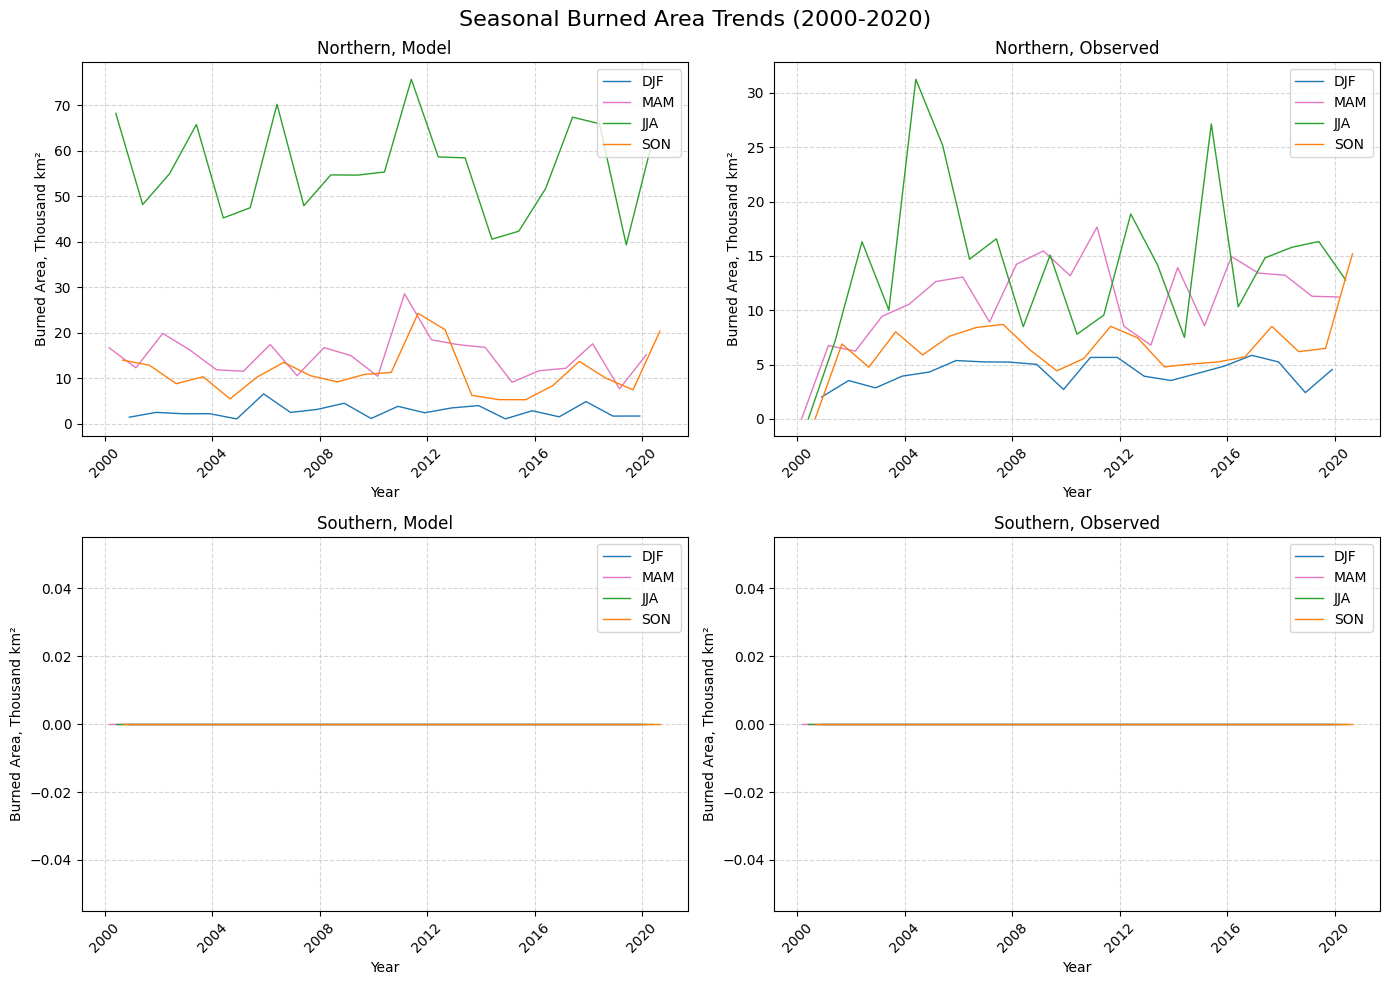

In [ ]:
# Suitable for the global map
fig, ax = plt.subplots(figsize=(14, 10), nrows=2, ncols=2)
fig.suptitle(f'Seasonal Burned Area Trends ({start_year}-{end_year})', fontsize=16)

# Northern Hemisphere
model_seasonal_NH.sel(time=(model_seasonal_NH.season == 'DJF')).plot(ax = ax[0][0],
           color='tab:blue', linewidth=1, label='DJF', linestyle='-')
observed_seasonal_NH.sel(time=(observed_seasonal_NH.season == 'DJF')).plot(ax = ax[0][1],
           color='tab:blue', linewidth=1, label='DJF', linestyle='-')

model_seasonal_NH.sel(time=(model_seasonal_NH.season == 'MAM')).plot(ax = ax[0][0],
           color='tab:pink', linewidth=1, label='MAM', linestyle='-')
observed_seasonal_NH.sel(time=(observed_seasonal_NH.season == 'MAM')).plot(ax = ax[0][1],
           color='tab:pink', linewidth=1, label='MAM', linestyle='-')

model_seasonal_NH.sel(time=(model_seasonal_NH.season == 'JJA')).plot(ax = ax[0][0],
           color='tab:green', linewidth=1, label='JJA', linestyle='-')
observed_seasonal_NH.sel(time=(observed_seasonal_NH.season == 'JJA')).plot(ax = ax[0][1],
           color='tab:green', linewidth=1, label='JJA', linestyle='-')

model_seasonal_NH.sel(time=(model_seasonal_NH.season == 'SON')).plot(ax = ax[0][0],
           color='tab:orange', linewidth=1, label='SON', linestyle='-')
observed_seasonal_NH.sel(time=(observed_seasonal_NH.season == 'SON')).plot(ax = ax[0][1],
           color='tab:orange', linewidth=1, label='SON', linestyle='-')

ax[0][0].set_title('Northern, Model', fontsize=12)
ax[0][1].set_title('Northern, Observed', fontsize=12)

# Southern Hemisphere
model_seasonal_SH.sel(time=(model_seasonal_SH.season == 'DJF')).plot(ax = ax[1][0],
           color='tab:blue', linewidth=1, label='DJF', linestyle='-')
observed_seasonal_SH.sel(time=(observed_seasonal_SH.season == 'DJF')).plot(ax = ax[1][1],
           color='tab:blue', linewidth=1, label='DJF', linestyle='-')
model_seasonal_SH.sel(time=(model_seasonal_SH.season == 'MAM')).plot(ax = ax[1][0],
           color='tab:pink', linewidth=1, label='MAM', linestyle='-')
observed_seasonal_SH.sel(time=(observed_seasonal_SH.season == 'MAM')).plot(ax = ax[1][1],
           color='tab:pink', linewidth=1, label='MAM', linestyle='-')

model_seasonal_SH.sel(time=(model_seasonal_SH.season == 'JJA')).plot(ax = ax[1][0],
           color='tab:green', linewidth=1, label='JJA', linestyle='-')
observed_seasonal_SH.sel(time=(observed_seasonal_SH.season == 'JJA')).plot(ax = ax[1][1],
           color='tab:green', linewidth=1, label='JJA', linestyle='-')

model_seasonal_SH.sel(time=(model_seasonal_SH.season == 'SON')).plot(ax = ax[1][0],
           color='tab:orange', linewidth=1, label='SON', linestyle='-')
observed_seasonal_SH.sel(time=(observed_seasonal_SH.season == 'SON')).plot(ax = ax[1][1],
           color='tab:orange', linewidth=1, label='SON', linestyle='-')

ax[1][0].set_title('Southern, Model', fontsize=12)
ax[1][1].set_title('Southern, Observed', fontsize=12)

for a in ax.flat:
  a.grid(True, linestyle='--', alpha=0.5)
  a.legend(loc='upper right')
  a.set_xlabel('Year', fontsize=10)
  a.set_ylabel(f'Burned Area, {units_scaled}', fontsize=10)
  a.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_path}/seasonal_time_series_NH_SH.tiff')

# Spatial Pattern Analysis


*   Mean Burned Area (+ by season)
*   Normalized Mean Bias (+ by season)
*   Mean Burned Area Difference (Model-Observed) by season



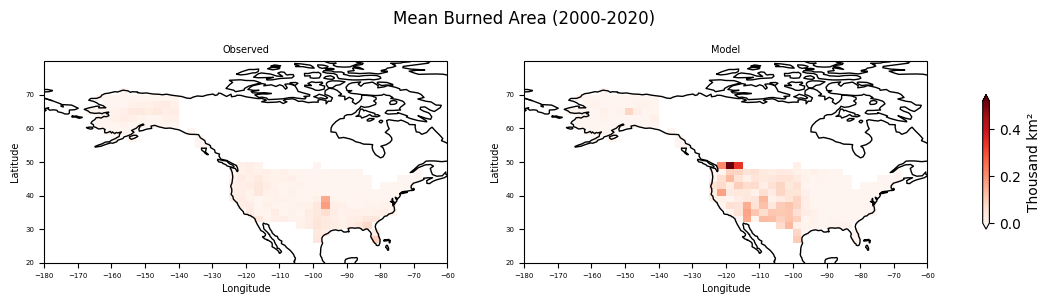

In [ ]:
# Visualizing the mean burned area
model_mean = model[model_var].mean(dim='time', skipna=True)/scale_factor
observed_mean = observed[observed_var].mean(dim='time', skipna=True)/scale_factor
vmin_global = 0
vmax_global = model_mean.max().item()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'Mean Burned Area ({start_year}-{end_year})', x=0.42, y=0.92)

ax[0].set_position([0.02,  0.52, 0.42, 0.42])
ax[1].set_position([0.52,  0.52, 0.42, 0.42])
ax[0].set_title('Observed', fontsize=7)
ax[1].set_title('Model', fontsize=7)

plot0 = observed_mean.plot(ax=ax[0], cmap='Reds', robust=True, vmin=vmin_global,
                           vmax=vmax_global, add_colorbar=False, add_labels=False)

plot1 = model_mean.plot(ax=ax[1], cmap='Reds', robust=True, vmin=vmin_global,
                            vmax=vmax_global, add_colorbar=False, add_labels=False)
# Adding a single colorbar spanning all subplots
cbar = fig.colorbar(plot0, ax=ax.ravel().tolist(), shrink=0.4, orientation='vertical',
                    label=units_scaled, pad=0.05, extend='both')

for a in ax:
  a.coastlines()
  a.set_xticks(range(lon_borders_maps[0], lon_borders_maps[1], lon_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_yticks(range(lat_borders_maps[0], lat_borders_maps[1], lat_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_xlabel('Longitude', fontsize=7)
  a.set_ylabel('Latitude', fontsize=7)
  a.tick_params(axis='x', labelsize=5)
  a.tick_params(axis='y', labelsize=5)

plt.savefig(f'{output_path}/mean_burned_area_map.tiff')

In [ ]:
model_seasons = model[model_var].groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).mean(skipna=True)/scale_factor
observed_seasons = observed[observed_var].groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).mean(skipna=True)/scale_factor

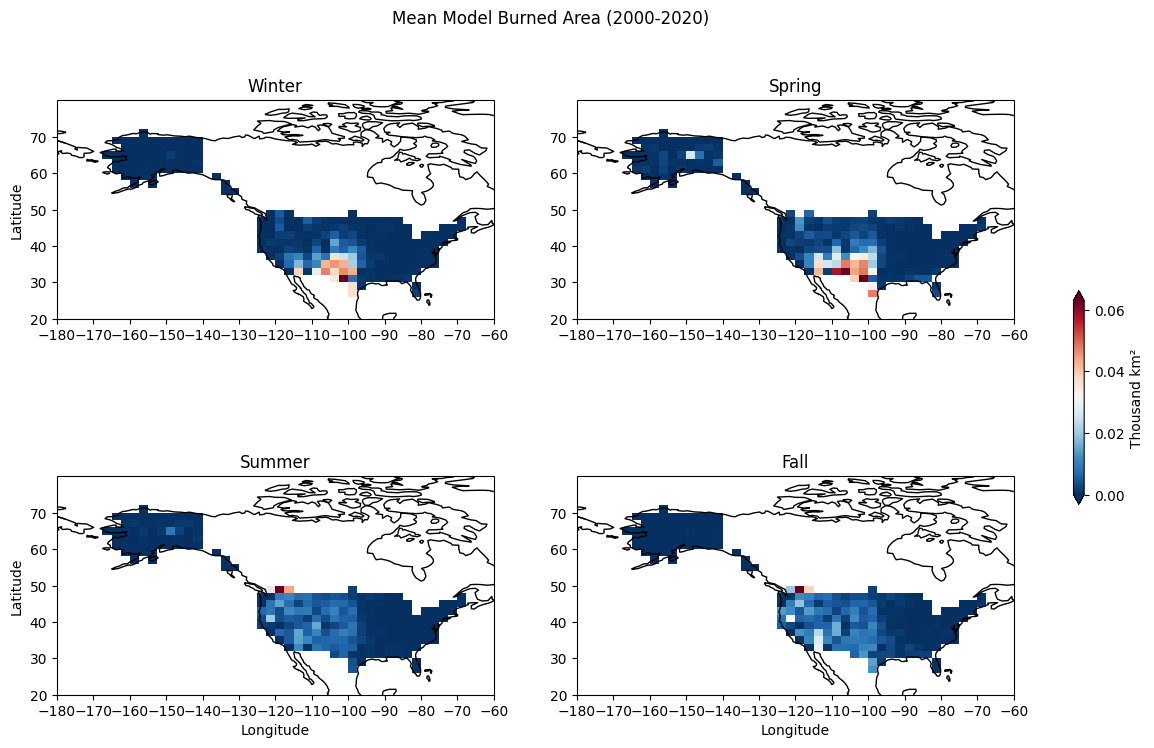

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(13, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'Mean Model Burned Area ({start_year}-{end_year})', x=0.4)
# fig.set_dpi(150)

ax[0][0].set_position([0.02,  0.52, 0.42, 0.42])
ax[0][1].set_position([0.52,  0.52, 0.42, 0.42])
ax[1][0].set_position([0.02,  0.05, 0.42, 0.42])
ax[1][1].set_position([0.52,  0.05, 0.42, 0.42])

plot0 = model_seasons.sel(season='DJF').plot(ax=ax[0][0], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[0][0].set_title('Winter')
ax[0][0].set_ylabel('Latitude')

plot1 = model_seasons.sel(season='MAM').plot(ax=ax[0][1], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[0][1].set_title('Spring')

plot2 = model_seasons.sel(season='JJA').plot(ax=ax[1][0], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[1][0].set_title('Summer')
ax[1][0].set_ylabel('Latitude')
ax[1][0].set_xlabel('Longitude')

plot3 = model_seasons.sel(season='SON').plot(ax=ax[1][1], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[1][1].set_title('Fall')
ax[1][1].set_xlabel('Longitude')

# Add a single colorbar spanning all subplots
cbar = fig.colorbar(plot0, ax=ax.ravel().tolist(), shrink=0.3, orientation='vertical', label='Thousand km²', pad=0.05, extend='both')

for a in ax.flat:
  a.coastlines()
  a.set_xticks(range(lon_borders_maps[0], lon_borders_maps[1], lon_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_yticks(range(lat_borders_maps[0], lat_borders_maps[1], lat_borders_maps[2]), crs=ccrs.PlateCarree())

plt.savefig(f'{output_path}/seasonal_mean_model_burned_area_map.tiff')

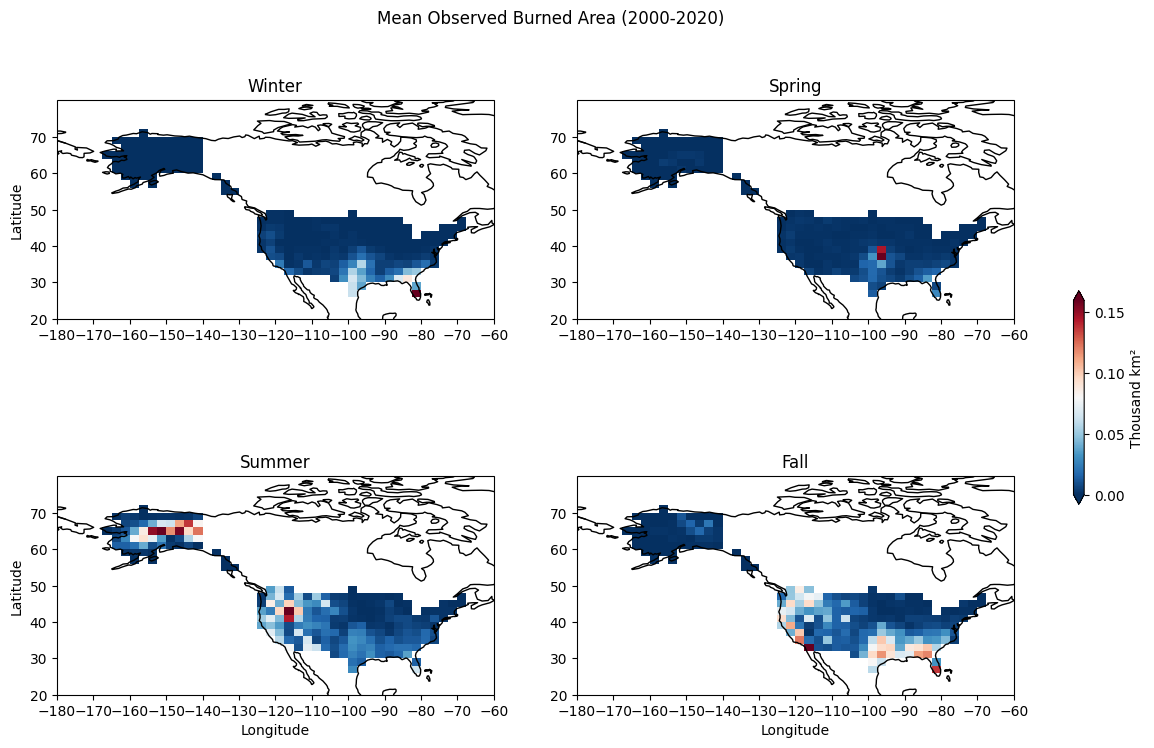

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(13, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'Mean Observed Burned Area ({start_year}-{end_year})', x=0.4)
# fig.set_dpi(150)

ax[0][0].set_position([0.02,  0.52, 0.42, 0.42])
ax[0][1].set_position([0.52,  0.52, 0.42, 0.42])
ax[1][0].set_position([0.02,  0.05, 0.42, 0.42])
ax[1][1].set_position([0.52,  0.05, 0.42, 0.42])

plot0 = observed_seasons.sel(season='DJF').plot(ax=ax[0][0], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[0][0].set_title('Winter')
ax[0][0].set_ylabel('Latitude')

plot1 = observed_seasons.sel(season='MAM').plot(ax=ax[0][1], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[0][1].set_title('Spring')

plot2 = observed_seasons.sel(season='JJA').plot(ax=ax[1][0], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[1][0].set_title('Summer')
ax[1][0].set_ylabel('Latitude')
ax[1][0].set_xlabel('Longitude')

plot3 = observed_seasons.sel(season='SON').plot(ax=ax[1][1], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[1][1].set_title('Fall')
ax[1][1].set_xlabel('Longitude')

# Add a single colorbar spanning all subplots
cbar = fig.colorbar(plot0, ax=ax.ravel().tolist(), shrink=0.3, orientation='vertical', label='Thousand km²', pad=0.05, extend='both')

for a in ax.flat:
  a.coastlines()
  a.set_xticks(range(lon_borders_maps[0], lon_borders_maps[1], lon_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_yticks(range(lat_borders_maps[0], lat_borders_maps[1], lat_borders_maps[2]), crs=ccrs.PlateCarree())

plt.savefig(f'{output_path}/seasonal_mean_observed_burned_area_map.tiff')

In [ ]:
# Seasonal means: results in (lat, lon, season) with season = DJF/MAM/JJA/SON
SEASON_MAP = {"DJF": "winter", "MAM": "spring", "JJA": "summer", "SON": "fall"}

rho_results = {}
for season_code, season_name in SEASON_MAP.items():
    o = observed_seasons.sel(season=season_code).values.ravel()
    s = model_seasons.sel(season=season_code).values.ravel()

    mask = np.isfinite(o) & np.isfinite(s)
    rho, pval = spearmanr(o[mask], s[mask])
    rho_results[season_name] = rho

    print(f"{season_name:>6}: rho = {rho:.4f}  (p = {pval:.4e},  n = {mask.sum()} cells)")

rho_winter = rho_results["winter"]
rho_spring = rho_results["spring"]
rho_summer = rho_results["summer"]
rho_fall = rho_results["fall"]

winter: rho = 0.6456  (p = 1.6145e-28,  n = 230 cells)
spring: rho = 0.4331  (p = 6.1918e-12,  n = 230 cells)
summer: rho = 0.4568  (p = 2.9414e-13,  n = 230 cells)
  fall: rho = 0.6453  (p = 1.7812e-28,  n = 230 cells)


In [ ]:
seasonal_model = model[model_var].groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"]))
seasonal_observed = observed[observed_var].groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"]))

nmb_winter = ((seasonal_model['DJF'].sum(dim='time', skipna=True)) - (seasonal_observed['DJF'].sum(dim='time', skipna=True))) / (seasonal_observed['DJF'].sum(dim='time', skipna=True))
nmb_spring = ((seasonal_model['MAM'].sum(dim='time', skipna=True)) - (seasonal_observed['MAM'].sum(dim='time', skipna=True))) / (seasonal_observed['MAM'].sum(dim='time', skipna=True))
nmb_summer = ((seasonal_model['JJA'].sum(dim='time', skipna=True)) - (seasonal_observed['JJA'].sum(dim='time', skipna=True))) / (seasonal_observed['JJA'].sum(dim='time', skipna=True))
nmb_fall = ((seasonal_model['SON'].sum(dim='time', skipna=True)) - (seasonal_observed['SON'].sum(dim='time', skipna=True))) / (seasonal_observed['SON'].sum(dim='time', skipna=True))

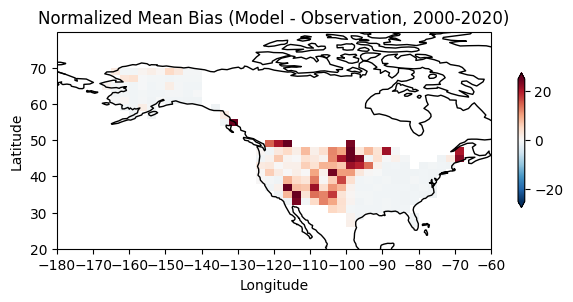

In [ ]:
# NMB
# https://www.qualityml.org/1.0/metrics/NormalizedMeanBias
NMB = ((model[model_var]-observed[observed_var]).sum(dim='time', skipna=True))/(observed[observed_var].sum(dim='time', skipna=True))

# Plot
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': ccrs.PlateCarree()})
NMB.plot(ax=ax, cbar_kwargs={'shrink': 0.25, 'orientation': 'vertical', 'extend': 'both', 'label': ''}, cmap='RdBu_r', robust=True)
ax.set_title(f'Normalized Mean Bias (Model - Observation, {start_year}-{end_year})')
ax.coastlines()
ax.set_xticks(range(lon_borders_maps[0], lon_borders_maps[1], lon_borders_maps[2]), crs=ccrs.PlateCarree())
ax.set_yticks(range(lat_borders_maps[0], lat_borders_maps[1], lat_borders_maps[2]), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.savefig(f'{output_path}/normalized_mean_bias_map.tiff')

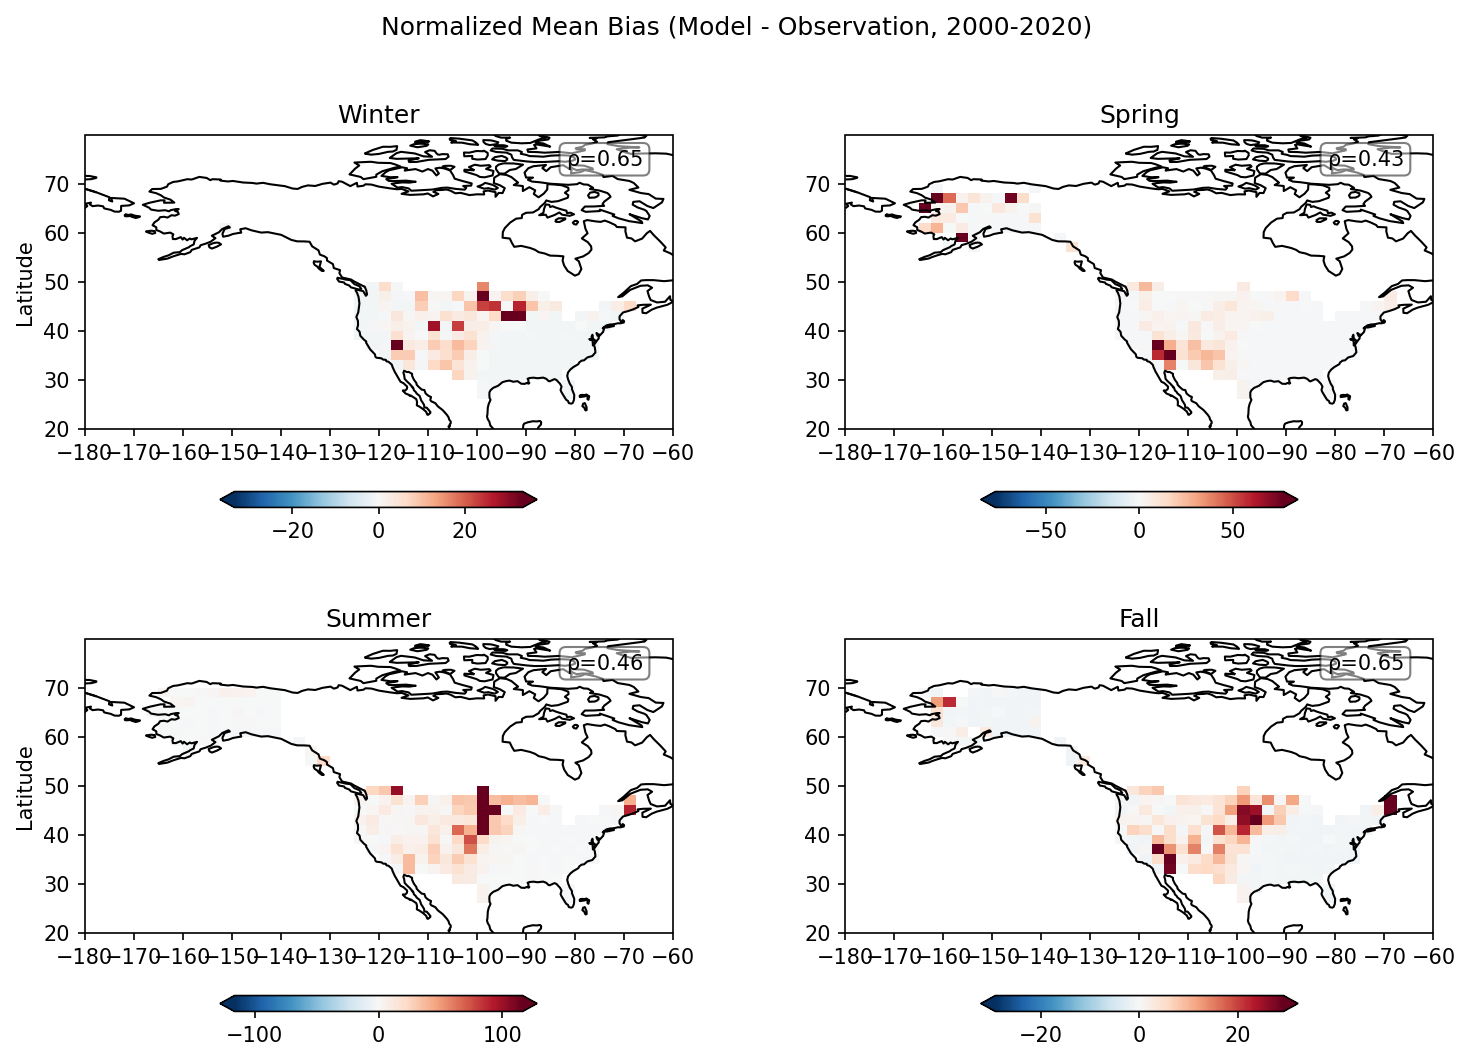

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'Normalized Mean Bias (Model - Observation, {start_year}-{end_year})', x=0.5)
fig.set_dpi(150)

ax[0][0].set_position([0.02,  0.52, 0.42, 0.42])
ax[0][1].set_position([0.52,  0.52, 0.42, 0.42])
ax[1][0].set_position([0.02,  0.05, 0.42, 0.42])
ax[1][1].set_position([0.52,  0.05, 0.42, 0.42])

plot0 = nmb_winter.plot(ax=ax[0][0], cmap='RdBu_r', robust=True, add_colorbar=True, add_labels=False,
                        cbar_kwargs={'shrink': 0.5, 'orientation': 'horizontal', 'extend': 'both', 'label': ''})
ax[0][0].set_title('Winter')
ax[0][0].text(x=0.95, y=0.95, s=f'ρ={rho_winter:.2f}', transform=ax[0][0].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')
ax[0][0].set_ylabel('Latitude')

plot1 = nmb_spring.plot(ax=ax[0][1], cmap='RdBu_r', robust=True, add_colorbar=True, add_labels=False,
                        cbar_kwargs={'shrink': 0.5, 'orientation': 'horizontal', 'extend': 'both', 'label': ''})
ax[0][1].set_title('Spring')
ax[0][1].text(x=0.95, y=0.95, s=f'ρ={rho_spring:.2f}', transform=ax[0][1].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')

plot2 = nmb_summer.plot(ax=ax[1][0], cmap='RdBu_r', robust=True, add_colorbar=True, add_labels=False,
                        cbar_kwargs={'shrink': 0.5, 'orientation': 'horizontal', 'extend': 'both', 'label': ''})
ax[1][0].set_title('Summer')
ax[1][0].text(x=0.95, y=0.95, s=f'ρ={rho_summer:.2f}', transform=ax[1][0].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')
ax[1][0].set_ylabel('Latitude')
# ax[1][0].set_xlabel('Longitude')

plot3 = nmb_fall.plot(ax=ax[1][1], cmap='RdBu_r', robust=True, add_colorbar=True, add_labels=False,
                      cbar_kwargs={'shrink': 0.5, 'orientation': 'horizontal', 'extend': 'both', 'label': ''})
ax[1][1].set_title('Fall')
ax[1][1].text(x=0.95, y=0.95, s=f'ρ={rho_fall:.2f}', transform=ax[1][1].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')
# ax[1][1].set_xlabel('Longitude')

for a in ax.flat:
  a.coastlines()
  a.set_xticks(range(lon_borders_maps[0], lon_borders_maps[1], lon_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_yticks(range(lat_borders_maps[0], lat_borders_maps[1], lat_borders_maps[2]), crs=ccrs.PlateCarree())
plt.savefig(f'{output_path}/seasonal_normalized_mean_bias_map.tiff')

In [ ]:
vmin_global = float(np.nanmin([nmb_winter.where(np.isfinite(nmb_winter)).min(),
                                nmb_spring.where(np.isfinite(nmb_spring)).min(),
                                nmb_summer.where(np.isfinite(nmb_summer)).min(),
                                nmb_fall.where(np.isfinite(nmb_fall)).min()]))

vmax_global = float(np.nanmax([nmb_winter.where(np.isfinite(nmb_winter)).max(),
                                nmb_spring.where(np.isfinite(nmb_spring)).max(),
                                nmb_summer.where(np.isfinite(nmb_summer)).max(),
                                nmb_fall.where(np.isfinite(nmb_fall)).max()]))

print(vmin_global)
print(vmax_global)

-0.9999999999671103
267.4776005587604


In [ ]:
seasonal_spatial_diff = xr.Dataset()
seasonal_spatial_diff['BA_diff'] = (model_seasons - observed_seasons)/scale_factor

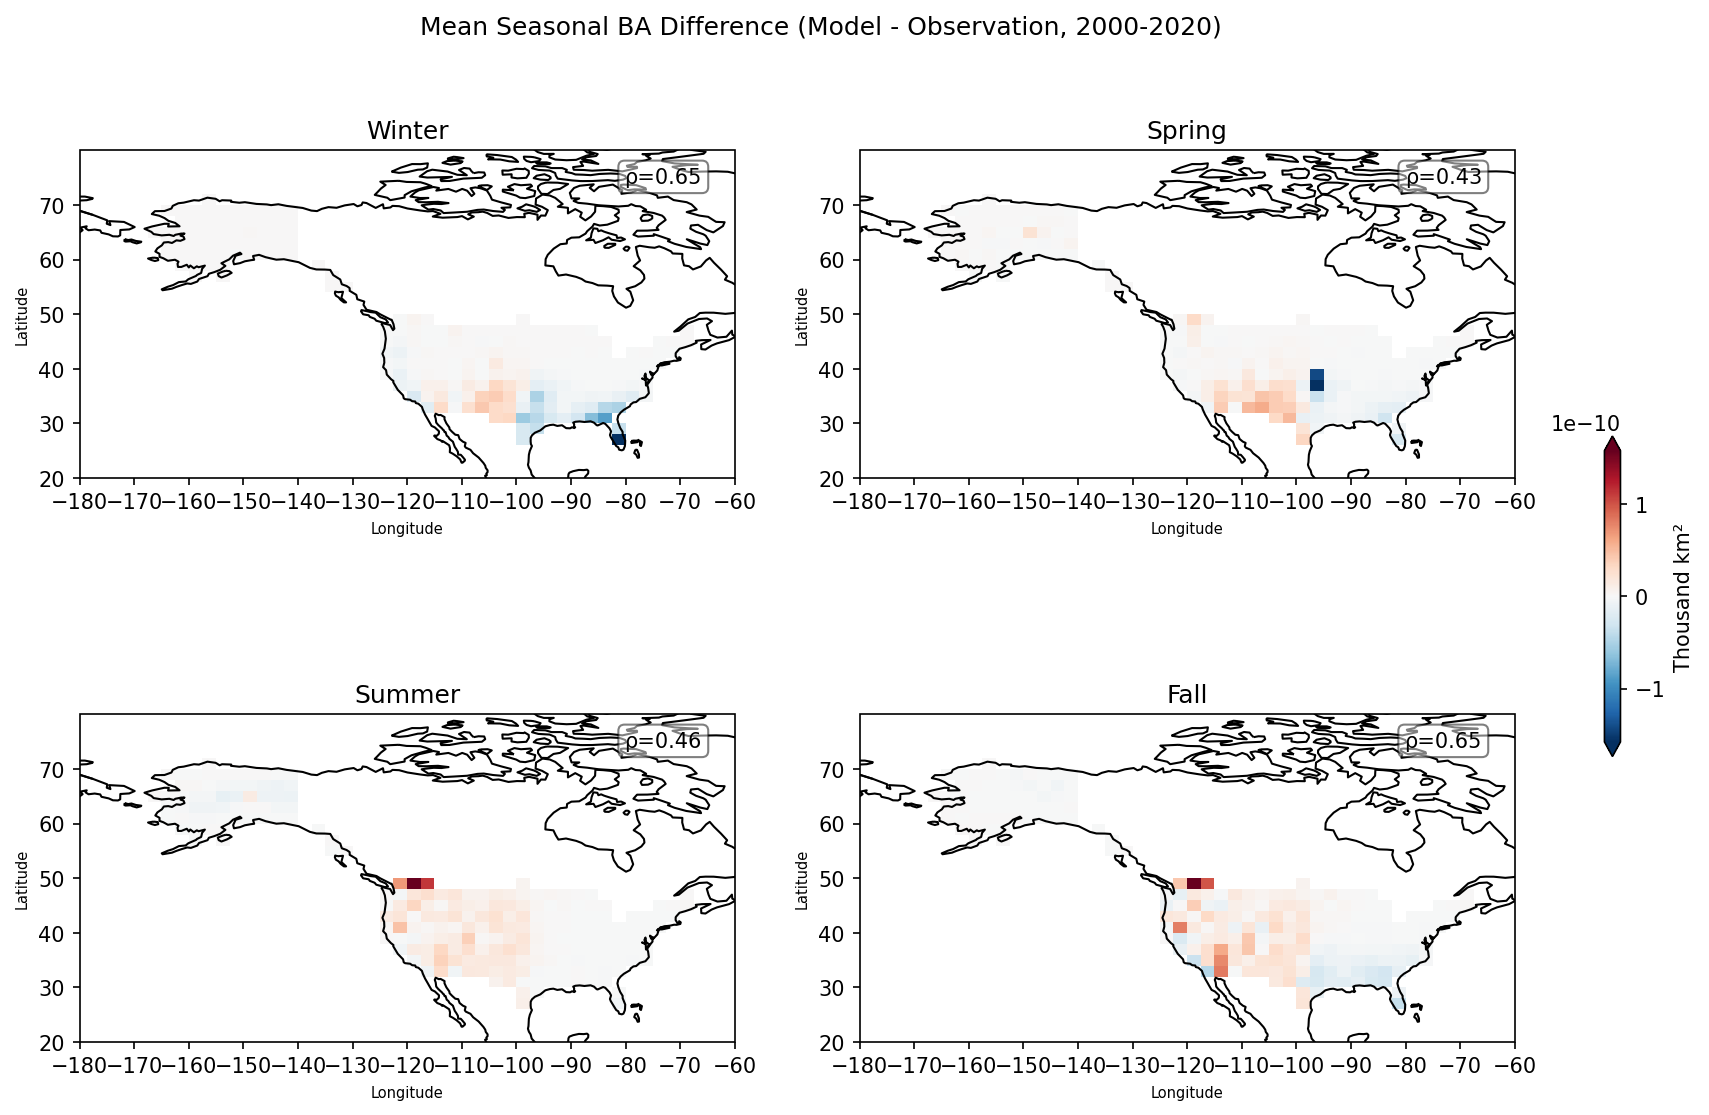

In [ ]:
vmin_global = -1
vmax_global = 1

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(13, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'Mean Seasonal BA Difference (Model - Observation, {start_year}-{end_year})', x=0.4)
fig.set_dpi(150)

ax[0][0].set_position([0.02,  0.52, 0.42, 0.42])
ax[0][1].set_position([0.52,  0.52, 0.42, 0.42])
ax[1][0].set_position([0.02,  0.05, 0.42, 0.42])
ax[1][1].set_position([0.52,  0.05, 0.42, 0.42])

plot0 = (seasonal_spatial_diff['BA_diff']).isel(season=0).plot(ax=ax[0][0], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[0][0].set_title('Winter')
ax[0][0].text(x=0.95, y=0.95, s=f'ρ={rho_winter:.2f}', transform=ax[0][0].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')
ax[0][0].set_ylabel('Latitude')

plot1 = (seasonal_spatial_diff['BA_diff']).isel(season=1).plot(ax=ax[0][1], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[0][1].set_title('Spring')
ax[0][1].text(x=0.95, y=0.95, s=f'ρ={rho_spring:.2f}', transform=ax[0][1].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')

plot2 = (seasonal_spatial_diff['BA_diff']).isel(season=2).plot(ax=ax[1][0], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[1][0].set_title('Summer')
ax[1][0].text(x=0.95, y=0.95, s=f'ρ={rho_summer:.2f}', transform=ax[1][0].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')
ax[1][0].set_ylabel('Latitude')
ax[1][0].set_xlabel('Longitude')

plot3 = (seasonal_spatial_diff['BA_diff']).isel(season=3).plot(ax=ax[1][1], cmap='RdBu_r', robust=False, add_colorbar=False, add_labels=False)
ax[1][1].set_title('Fall')
ax[1][1].text(x=0.95, y=0.95, s=f'ρ={rho_fall:.2f}', transform=ax[1][1].transAxes, bbox = {'boxstyle':'round', 'facecolor':'white', 'alpha':0.5},
         horizontalalignment='right', verticalalignment='top')
ax[1][1].set_xlabel('Longitude')

# Add a single colorbar spanning all subplots
cbar = fig.colorbar(plot0, ax=ax.ravel().tolist(), shrink=0.3, orientation='vertical', label='Thousand km²', pad=0.05, extend='both')

for a in ax.flat:
  a.coastlines()
  a.set_xticks(range(lon_borders_maps[0], lon_borders_maps[1], lon_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_yticks(range(lat_borders_maps[0], lat_borders_maps[1], lat_borders_maps[2]), crs=ccrs.PlateCarree())
  a.set_xlabel('Longitude', fontsize=7)
  a.set_ylabel('Latitude', fontsize=7)
plt.savefig(f'{output_path}/seasonal_mean_BA_diff_map.tiff')

# Distribution Analysis


*   Histogram
*   Jensen-Shannon Divergence
*   Wilcoxon rank sum test statistic
*   Rank-Biserial Correlation



In [ ]:
observed_sum = observed[observed_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor
model_sum = model[model_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor

model_vals = model_sum[~np.isnan(model_sum)].values
obs_vals = observed_sum[~np.isnan(observed_sum)].values

# 2. Define global bins based on the max of observed datasets
bins = np.linspace(0, max(model_vals.max(), obs_vals.max()), num=50)

# 3. Calculate Histograms (The "PDFs")
p_hist, p_edges = np.histogram(model_vals, bins=bins)
q_hist, q_edges = np.histogram(obs_vals, bins=bins)

p = p_hist / p_hist.sum()
q = q_hist / q_hist.sum()

# Jensen-shannon divergence
# Explanation: https://www.datacamp.com/tutorial/kl-divergence

js_distance = distance.jensenshannon(p, q)
js_divergence = js_distance**2

print(f"Jensen-Shannon Divergence: {js_divergence:.4f}")

# JSD is in the range of [0, ln2] with smaller values describing better fit

Jensen-Shannon Divergence: 0.1385


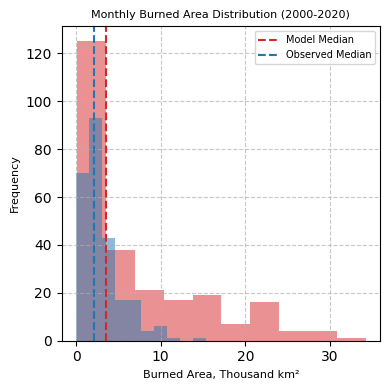

In [ ]:
simulated_median = np.median(model_sum.values)
observed_median = np.median(observed_sum.values)

fig, ax = plt.subplots(figsize=(4, 4))

# Plot Histogram
ax.hist(model_sum.values, color='tab:red', alpha=0.5)
ax.hist(observed_sum.values, color='tab:blue', alpha=0.5)

# Add vertical lines for means
ax.axvline(simulated_median, color='tab:red', linestyle='--', label=f'Model Median')
ax.axvline(observed_median, color='tab:blue', linestyle='--', label=f'Observed Median')

ax.set_title('Monthly Burned Area Distribution (2000-2020)', fontsize=8)
ax.set_xlabel(f'Burned Area, {units_scaled}', fontsize=8)
ax.set_ylabel('Frequency', fontsize=8)
ax.legend(fontsize=7)
ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig(f'{output_path}/burned_area_distribution.tiff')

In [ ]:
def perkins_skill_score(observed_data, simulated_data, num_bins=50):
    # Remove NaN values
    observed_data = observed_data[~np.isnan(observed_data)]
    simulated_data = simulated_data[~np.isnan(simulated_data)]

    # Exclude BAs close to zero (filter for positive values) and apply log(1 + x) transformation
    observed_data_transformed = np.log1p(observed_data[observed_data > 0])
    simulated_data_transformed = np.log1p(simulated_data[simulated_data > 0])

    # Handle cases where one or both datasets become empty after filtering
    if len(observed_data_transformed) == 0 or len(simulated_data_transformed) == 0:
        # If no positive values, PSS cannot be calculated meaningfully
        return np.nan

    # Determine global bins based on the combined range of both transformed datasets
    min_val = min(observed_data_transformed.min(), simulated_data_transformed.min())
    max_val = max(observed_data_transformed.max(), simulated_data_transformed.max())

    # Handle cases where min_val might be equal to max_val if all values are identical
    if min_val == max_val:
        # If all transformed values are identical, create a very small bin range around that value
        bins = np.array([min_val - 1e-6, max_val + 1e-6])
    else:
        bins = np.linspace(min_val, max_val, num=num_bins + 1)

    # Calculate histograms (frequencies) for observed and simulated data
    hist_observed, _ = np.histogram(observed_data_transformed, bins=bins, density=False)
    hist_simulated, _ = np.histogram(simulated_data_transformed, bins=bins, density=False)

    # Normalize histograms to get probability distributions
    # Ensure no division by zero if a histogram sum is zero
    p_observed = hist_observed / hist_observed.sum() if hist_observed.sum() > 0 else np.zeros_like(hist_observed, dtype=float)
    p_simulated = hist_simulated / hist_simulated.sum() if hist_simulated.sum() > 0 else np.zeros_like(hist_simulated, dtype=float)

    # Calculate the Perkins Skill Score
    # PSS = sum_{i=1 to N} min(p_observed[i], p_simulated[i])
    pss = np.sum(np.minimum(p_observed, p_simulated))
    return pss

# Ensure observed_sum and simulated_sum are numpy arrays for consistency
obs_vals_pss = observed_sum.values.flatten()
model_vals_pss = model_sum.values.flatten()

# Calculate Perkins Skill Score with log-transformed and filtered data
pss_score = perkins_skill_score(obs_vals_pss, model_vals_pss, num_bins=50)
print(f"Perkins Skill Score (log-transformed, >0 BA): {pss_score:.4f}")

Perkins Skill Score (log-transformed, >0 BA): 0.5500


In [ ]:
# https://scienceinsights.org/what-is-the-wilcoxon-rank-sum-test-and-when-to-use-it/
# https://metricgate.com/docs/rank-biserial-correlation/
from scipy import stats
from scipy.stats import ranksums
U_stat, p_value = ranksums(model_sum.values, observed_sum.values)
r_rb = 1-(2*U_stat)/(len(model_sum.values)*len(model_sum.values))
print(f'Wilcoxon rank sum test statistic: {U_stat}, p-value: {p_value}\nRank-Biserial Correlation: {r_rb}')

Wilcoxon rank sum test statistic: 3.4708330531983678, p-value: 0.0005188464689992164
Rank-Biserial Correlation: 0.9998906893092341


# Exceedance probability


*   Monthly Exceedance Probability (AEP) Curve (+ by season)



In [ ]:
def get_aep(data, var, season):
  BA_dataset = data[var].sum(dim=['latitude', 'longitude']).to_dataset(name='spatial_total')
  if season != 'year':
    BA_dataset = BA_dataset.groupby(time=SeasonResampler([f"{season}"], drop_incomplete=True)).sum()
  BA_dataset = BA_dataset.assign(rank=BA_dataset['spatial_total'].rank(dim='time'))
  BA_dataset= BA_dataset.assign(ex_prob = (BA_dataset.sizes['time'] - BA_dataset['rank']) / BA_dataset.sizes['time'])
  BA_df = BA_dataset.to_dataframe().sort_values('ex_prob', ascending=False)
  return BA_df

In [ ]:
aep_year_model = get_aep(model, model_var, 'year')
aep_DJF_model = get_aep(model, model_var, 'DJF')
aep_MAM_model  = get_aep(model, model_var, 'MAM')
aep_JJA_model = get_aep(model, model_var, 'JJA')
aep_SON_model = get_aep(model, model_var, 'SON')
aep_year_model = get_aep(model, model_var, 'year')

aep_year_obs = get_aep(observed, observed_var, 'year')
aep_DJF_obs = get_aep(observed, observed_var, 'DJF')
aep_MAM_obs  = get_aep(observed, observed_var, 'MAM')
aep_JJA_obs = get_aep(observed, observed_var, 'JJA')
aep_SON_obs = get_aep(observed, observed_var, 'SON')
aep_year_obs = get_aep(observed, observed_var, 'year')

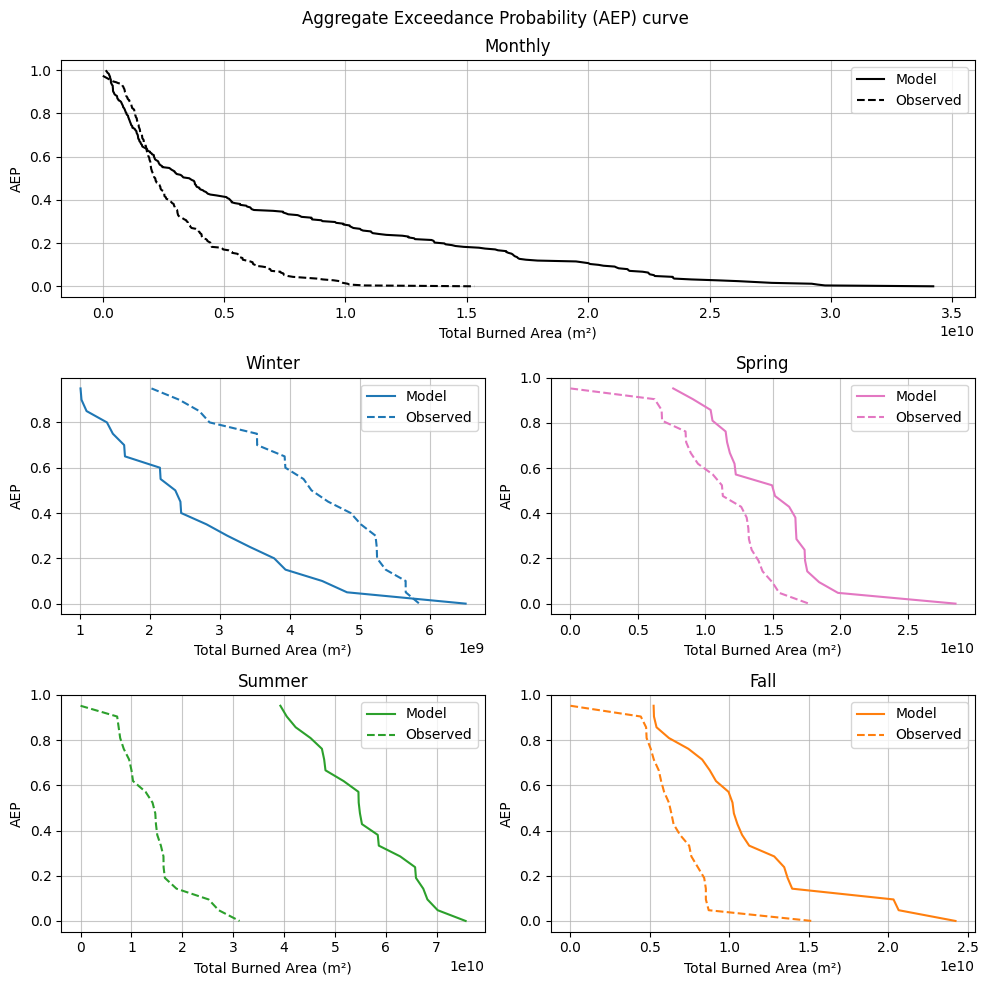

In [ ]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :]) # year
ax3 = fig.add_subplot(gs[1, 0]) # winter
ax5 = fig.add_subplot(gs[1, 1]) # spring
ax7 = fig.add_subplot(gs[2, 0]) # summer
ax9 = fig.add_subplot(gs[2, 1]) # fall

ax1.plot(aep_year_model['spatial_total'], aep_year_model['ex_prob'], label='Model', color='black')
ax1.plot(aep_year_obs['spatial_total'], aep_year_obs['ex_prob'], label='Observed', color='black', linestyle='--')
ax3.plot(aep_DJF_model['spatial_total'], aep_DJF_model['ex_prob'], label='Model', color='tab:blue')
ax3.plot(aep_DJF_obs['spatial_total'], aep_DJF_obs['ex_prob'], label='Observed', color='tab:blue', linestyle='--')
ax5.plot(aep_MAM_model['spatial_total'], aep_MAM_model['ex_prob'], label='Model', color='tab:pink')
ax5.plot(aep_MAM_obs['spatial_total'], aep_MAM_obs['ex_prob'], label='Observed', color='tab:pink', linestyle='--')
ax7.plot(aep_JJA_model['spatial_total'], aep_JJA_model['ex_prob'], label='Model', color='tab:green')
ax7.plot(aep_JJA_obs['spatial_total'], aep_JJA_obs['ex_prob'], label='Observed', color='tab:green', linestyle='--')
ax9.plot(aep_SON_model['spatial_total'], aep_SON_model['ex_prob'], label='Model', color='tab:orange')
ax9.plot(aep_SON_obs['spatial_total'], aep_SON_obs['ex_prob'], label='Observed', color='tab:orange', linestyle='--')

all_ax = [ax1, ax3, ax5, ax7, ax9]
for ax in all_ax:
  ax.set_xlabel('Total Burned Area (m²)')
  ax.set_ylabel('AEP')
  ax.set_title(f'{ax.get_title()}')
  ax.legend()
  ax.grid(True, alpha=0.7)

ax1.set_title('Monthly')
ax3.set_title('Winter')
ax5.set_title('Spring')
ax7.set_title('Summer')
ax9.set_title('Fall')

fig.suptitle('Aggregate Exceedance Probability (AEP) curve')
plt.tight_layout()
plt.savefig(f'{output_path}/aep_curve.tiff')

# Applying GACC Boundaries Mask
US GACC [shp files](https://data-nifc.opendata.arcgis.com/datasets/nifc::national-gacc-boundaries-public/about) and [regionmask](https://regionmask.readthedocs.io/en/stable/notebooks/geopandas.html) were used to create fire regions masks for US data

In [8]:
# Loading shapefile with US fire regions
usgacc = gp.read_file(us_gacc_path).reset_index(drop=True)[['GACCAbbrev', 'geometry']]
usgacc = usgacc.to_crs("EPSG:4326")

# Merging all subregions with the same abbreviation
regions_merged = usgacc.dissolve(by='GACCAbbrev', as_index=False)

In [ ]:
# Defining grid range and resolution for drawing the fire regions on a map with 2D mask
lon = np.arange(-170, -60, 0.1)
lat = np.arange(10, 90, 0.1)

# Creating fire regions 2D mask from shapefile
fireregions_mask_2D = regionmask.mask_geopandas(regions_merged, lon, lat)

# Cropping fire regions to the US area
fireregions_mask_2D_US = crop_to_region(fireregions_mask_2D, 'lat', 'lon', lat_borders, lon_borders)

/tmp/ipykernel_34220/1450972492.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_regions)


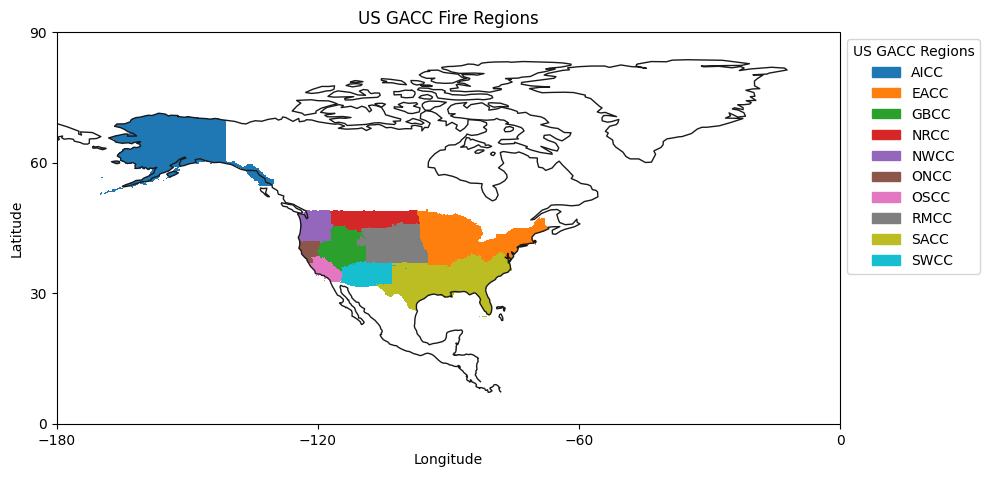

In [ ]:
# Plotting fire regions from 2D mask
f, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Get the list of region abbreviations
region_labels = regions_merged.GACCAbbrev.tolist()
num_regions = len(region_labels)

# Choose a colormap for distinct colors for each region
cmap = plt.cm.get_cmap('tab10', num_regions)

fireregions_mask_2D_US.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    cmap=cmap,
    vmin=0,
    vmax=num_regions - 1)

# Create custom legend handles and labels
legend_patches = []
for i, label in enumerate(region_labels):
    # Create a patch for each region with its corresponding color from the colormap
    patch = mpatches.Patch(color=cmap(i), label=label)
    legend_patches.append(patch)

# Add the legend to the plot
ax.legend(handles=legend_patches, loc='upper left', title="US GACC Regions", bbox_to_anchor=(1, 1))
ax.coastlines(color="0.1")
ax.set_xticks(range(-180, 10, 60), crs=ccrs.PlateCarree())
ax.set_yticks(range(0, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.title('US GACC Fire Regions')
plt.tight_layout()
plt.savefig(f'{output_path}/US_GACC_fire_regions.tiff')

In [ ]:
region_id_to_name = {i: name for i, name in enumerate(region_labels)}
print(region_id_to_name)

{0: 'AICC', 1: 'EACC', 2: 'GBCC', 3: 'NRCC', 4: 'NWCC', 5: 'ONCC', 6: 'OSCC', 7: 'RMCC', 8: 'SACC', 9: 'SWCC'}


In [ ]:
def create_3D_mask(data, regions):
  # Creating a grid for the fire regions mask to overlay observed data
  lon = np.asarray(data.longitude)[:-1]
  lat = np.asarray(data.latitude)
  fireregions_3D = regionmask.mask_3D_geopandas(regions, lon, lat)
  fireregions_3D = fireregions_3D.rename({'lat':'latitude', 'lon':'longitude'})
  return fireregions_3D

In [ ]:
model_mask = create_3D_mask(model_agg, regions_merged)
observed_mask = create_3D_mask(observed_agg, regions_merged)

lat_borders, lon_borders = [24.5, 80], [-180, -66.9]  # for mainland US
lat_borders_maps, lon_borders_maps = [20, 80, 10], [-180, -50, 10] # for mainland US (drawing map frame)

mask_US_obs = crop_to_region(observed_mask, 'latitude', 'longitude', lat_borders, lon_borders)
mask_US_model = crop_to_region(model_mask, 'latitude', 'longitude', lat_borders, lon_borders)

observed_US_regions = observed_agg.where(mask_US_obs)
model_US_regions = model_agg.where(mask_US_model)

Text(0, 0.5, 'Latitude')

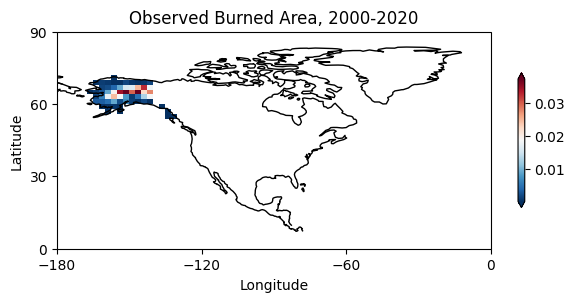

In [ ]:
# Reference figure
observed_US_regions_mean = observed_US_regions.mean(dim='time', skipna=True)/scale_factor

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': ccrs.PlateCarree()})
observed_US_regions_mean[observed_var].isel(region=0).plot(ax=ax, cmap='RdBu_r', robust=True,
          cbar_kwargs={'shrink': 0.25, 'orientation': 'vertical', 'extend': 'both', 'label': ''})
ax.set_title(f'Observed Burned Area, {start_year}-{end_year}')
ax.coastlines()
ax.set_xticks(range(-180, 10, 60), crs=ccrs.PlateCarree())
ax.set_yticks(range(0, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Analysis by US fire regions


*   Monthly Time Series
*   Time Series by season
*   Seasonal Mean Burned Area
*   Jensen-shannon divergence
*   Monthly Exceedance Probability (AEP) Curve
*   5-year Exceedance Probability (AEP) Curve



In [ ]:
# Calculating seasonal means
observed_seasonal_mean = observed_US_regions[observed_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).mean(skipna=True)/scale_factor
observed_seasonal_std = observed_US_regions[observed_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).std(skipna=True)/scale_factor

model_seasonal_mean = model_US_regions[model_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).mean(skipna=True)/scale_factor
model_seasonal_std = model_US_regions[model_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonGrouper(["DJF", "MAM", "JJA", "SON"])).std(skipna=True)/scale_factor

x_labels = observed_seasonal_mean.isel(region=1).season.values
x_model_positions = np.arange(len(x_labels))-0.1
x_obs_positions = np.arange(len(x_labels))+0.1

In [ ]:
observed_sum = observed_US_regions[observed_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor
model_sum = model_US_regions[model_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor

In [ ]:
model_seasonal_sum = model_US_regions[model_var].sum(dim=['latitude', 'longitude'],skipna=True).groupby(time=SeasonResampler(["DJF", "MAM", "JJA", "SON"],
                                                  drop_incomplete=True)).sum()/scale_factor
observed_seasonal_sum = observed_US_regions[observed_var].sum(dim=['latitude', 'longitude'], skipna=True).groupby(time=SeasonResampler(["DJF", "MAM", "JJA", "SON"],
                                                  drop_incomplete=True)).sum()/scale_factor

seasons = model_seasonal_sum.time.dt.season
model_seasonal_sum = model_seasonal_sum.assign_coords(season=seasons)
observed_seasonal_sum = observed_seasonal_sum.assign_coords(season=seasons)

In [ ]:
# Time series for every region (annual and seasonal)
for reg in np.arange(1, 10, 1):
  fig = plt.figure(figsize=(10, 10))
  fig.suptitle(f'{region_id_to_name[reg]}')
  gs = GridSpec(3, 2, figure=fig)
  ax1 = fig.add_subplot(gs[0, :]) # monthly time series
  ax3 = fig.add_subplot(gs[1, 0]) # seasonal boxplot
  ax5 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()) # map
  ax7 = fig.add_subplot(gs[2, 0]) # seasonal time series - simulated
  ax9 = fig.add_subplot(gs[2, 1]) # seasonal time series - observed

  # monthly time series
  model_sum.isel(region=reg).plot(ax=ax1, label='Simulated', linestyle='-', color='red', linewidth=0.75)
  observed_sum.isel(region=reg).plot(ax=ax1, label='Observed', linestyle='-', color='blue', linewidth=0.75)
  # ax1.set_xlabel('Time')
  ax1.set_ylabel(f'Burned Area, {units_scaled}', fontsize=7)
  ax1.set_title('Monthly Burned Area', fontsize=8)
  ax1.grid(True, linestyle='--', alpha=0.7)
  ax1.legend(loc='upper left', fontsize=7)

  # seasonal boxplot
  ax3.errorbar(x_model_positions, model_seasonal_mean.isel(region=reg).values, label='Simulated Mean ± Std',
              yerr=model_seasonal_std.isel(region=reg).values, fmt='ro', capsize=5)
  ax3.errorbar(x_obs_positions, observed_seasonal_mean.isel(region=reg).values, label='Observed Mean ± Std',
              yerr=observed_seasonal_std.isel(region=reg).values, fmt='bo', capsize=5)
  ax3.set_xticks(x_model_positions)
  ax3.set_xticklabels(x_labels)
  # ax3.set_xlabel('Season', fontsize=8)
  ax3.set_ylabel(f'Burned Area, {units_scaled}', fontsize=8)
  ax3.set_title(f'Seasonal Burned Area Mean ({start_year}-{end_year})', fontsize=8)
  ax3.grid(True, linestyle='--', alpha=0.7)
  ax3.legend(loc='upper left', fontsize=6)

  # map
  mask_US_model.isel(region=reg).plot(ax=ax5, add_colorbar=False, add_labels=False)
  ax5.coastlines()
  ax5.set_xticks(range(-180, -60, 60), crs=ccrs.PlateCarree())
  ax5.set_yticks(range(24, 80, 10), crs=ccrs.PlateCarree())
  # ax5.set_xlabel('Longitude')
  # ax5.set_ylabel('Latitude')

  # seasonal time series
  model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'MAM'), region=reg).plot(ax = ax7,
            color='tab:pink', linewidth=1, label='MAM', linestyle='-')

  observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'MAM'), region=reg).plot(ax = ax9,
            color='tab:pink', linewidth=1, label='MAM', linestyle='-')

  model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'JJA'), region=reg).plot(ax = ax7,
            color='tab:green', linewidth=1, label='JJA', linestyle='-')
  observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'JJA'), region=reg).plot(ax = ax9,
            color='tab:green', linewidth=1, label='JJA', linestyle='-')

  model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'SON'), region=reg).plot(ax = ax7,
            color='tab:orange', linewidth=1, label='SON', linestyle='-')
  observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'SON'), region=reg).plot(ax = ax9,
            color='tab:orange', linewidth=1, label='SON', linestyle='-')

  model_seasonal_sum.sel(time=(model_seasonal_sum.season == 'DJF'), region=reg).plot(ax = ax7,
            color='tab:blue', linewidth=1, label='DJF', linestyle='-')
  observed_seasonal_sum.sel(time=(observed_seasonal_sum.season == 'DJF'), region=reg).plot(ax = ax9,
            color='tab:blue', linewidth=1, label='DJF', linestyle='-')

  ax7.set_title('Model', fontsize=8)
  ax9.set_title('Observed', fontsize=8)

  for a in (ax7, ax9):
    a.grid(True, linestyle='--', alpha=0.5)
    a.legend(loc='upper left', fontsize=6)
    a.set_xlabel('Year', fontsize=8)
    a.set_ylabel(f'Burned Area, {units_scaled}', fontsize=8)
    a.tick_params(axis='x', size=4)

  plt.savefig(f'{output_path}/monthly_timeseries_region_{reg}.tiff')
  plt.clf()

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [ ]:
for reg in np.arange(1, 10, 1):
  observed_sum = observed_US_regions[observed_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor
  simulated_sum = model_US_regions[model_var].sum(dim=['latitude', 'longitude'], skipna=True)/scale_factor

  sim_region_data = simulated_sum.sel(region=reg)
  obs_region_data = observed_sum.sel(region=reg)

  sim_vals = sim_region_data[~np.isnan(sim_region_data)].values
  obs_vals = obs_region_data[~np.isnan(obs_region_data)].values

  # 2. Define global bins based on the max of observed datasets
  bins = np.linspace(0, max(sim_vals.max(), obs_vals.max()), num=50)

  # 3. Calculate Histograms (The "PDFs")
  # Use density=False initially to get counts, then normalize manually so the sum of p and q is exactly 1.0
  p_hist, p_edges = np.histogram(sim_vals, bins=bins)
  q_hist, q_edges = np.histogram(obs_vals, bins=bins)

  p = p_hist / p_hist.sum()
  q = q_hist / q_hist.sum()

  # Jensen-shannon divergence
  # Explanation: https://www.datacamp.com/tutorial/kl-divergence

  js_distance = distance.jensenshannon(p, q)
  js_divergence = js_distance**2

  print(f"Jensen-Shannon Divergence for {region_id_to_name[reg]}: {js_divergence:.4f}")

  # JSD is in the range of [0, ln2] with smaller values describing better fit

Jensen-Shannon Divergence for EACC: 0.1099
Jensen-Shannon Divergence for GBCC: 0.0912
Jensen-Shannon Divergence for NRCC: 0.0983
Jensen-Shannon Divergence for NWCC: 0.0828
Jensen-Shannon Divergence for ONCC: 0.0774
Jensen-Shannon Divergence for OSCC: 0.0631
Jensen-Shannon Divergence for RMCC: 0.1195
Jensen-Shannon Divergence for SACC: 0.1407
Jensen-Shannon Divergence for SWCC: 0.3726


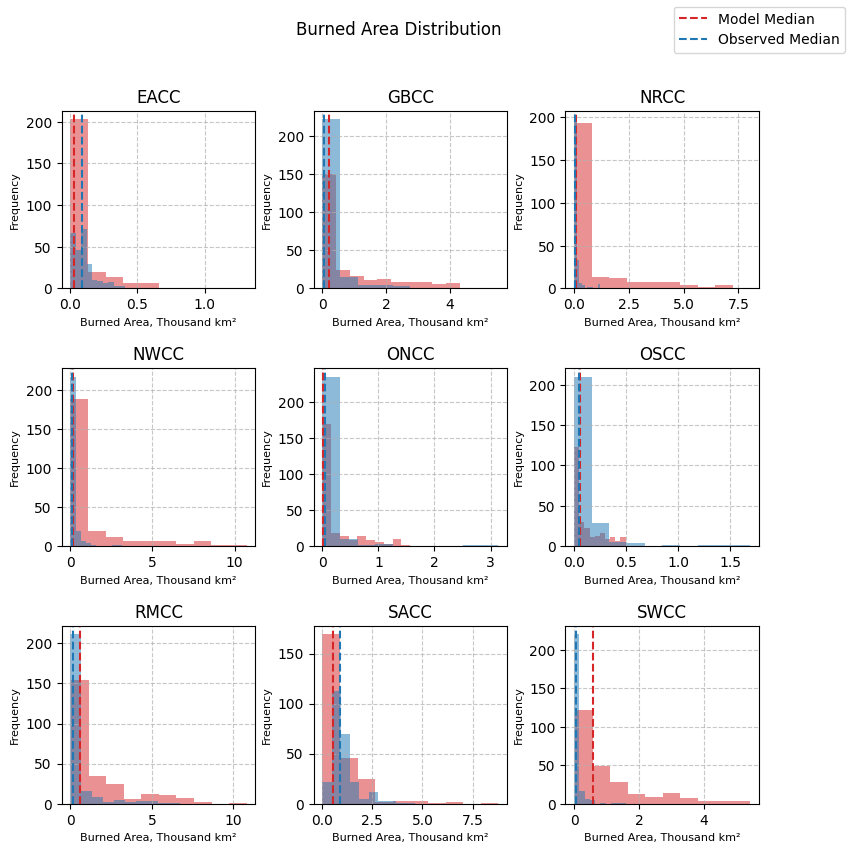

In [ ]:
fig = plt.figure(figsize=(9, 9))
fig.suptitle('Burned Area Distribution')

gs = GridSpec(nrows=3, ncols=3, width_ratios=[1, 1, 1], wspace=0.3,hspace=0.45)

for i, reg in enumerate(range(1, 10)):
  row = i // 3
  col = i % 3

  ax = fig.add_subplot(gs[row, col])

  ax.hist(simulated_sum.sel(region=reg).values, color='tab:red', alpha=0.5)
  ax.hist(observed_sum.sel(region=reg).values, color='tab:blue', alpha=0.5)

  simulated_median = np.median(simulated_sum.sel(region=reg).values)
  observed_median = np.median(observed_sum.sel(region=reg).values)

  ax.axvline(simulated_median, color='tab:red', linestyle='--', label=f'Model Median')
  ax.axvline(observed_median, color='tab:blue', linestyle='--', label=f'Observed Median')
  ax.set_xlabel(f'Burned Area, {units_scaled}', fontsize=8)
  ax.set_ylabel('Frequency', fontsize=8)
  ax.set_title(f'{region_id_to_name[reg]}')
  ax.grid(True, linestyle='--', alpha=0.7)

plt.figlegend(['Model Median', 'Observed Median'])
plt.savefig(f'{output_path}/monthly_aep_regions.tiff')

## AEP
What is the monthly aggregate exceedance probability?

In [ ]:
def get_aep_percentile(data, var, percent):
  percentile = float(data[var].quantile(percent))
  ep = round(float(1- data[data[var] >= percentile]['ex_prob'].values[0]), 2)
  return percentile, ep

In [ ]:
BA_df_reg1 = get_aep(model_US_regions.isel(region=1), model_var, 'year')

quantiles = {}
for percent in [0.75, 0.90, 0.99]:
  percentile, ep = get_aep_percentile(BA_df_reg1, 'spatial_total', percent)
  quantiles[percent] = (percentile, ep)
print(quantiles)

{0.75: (93335466.0, 0.75), 0.9: (283593785.6, 0.9), 0.99: (671326412.1600006, 0.99)}


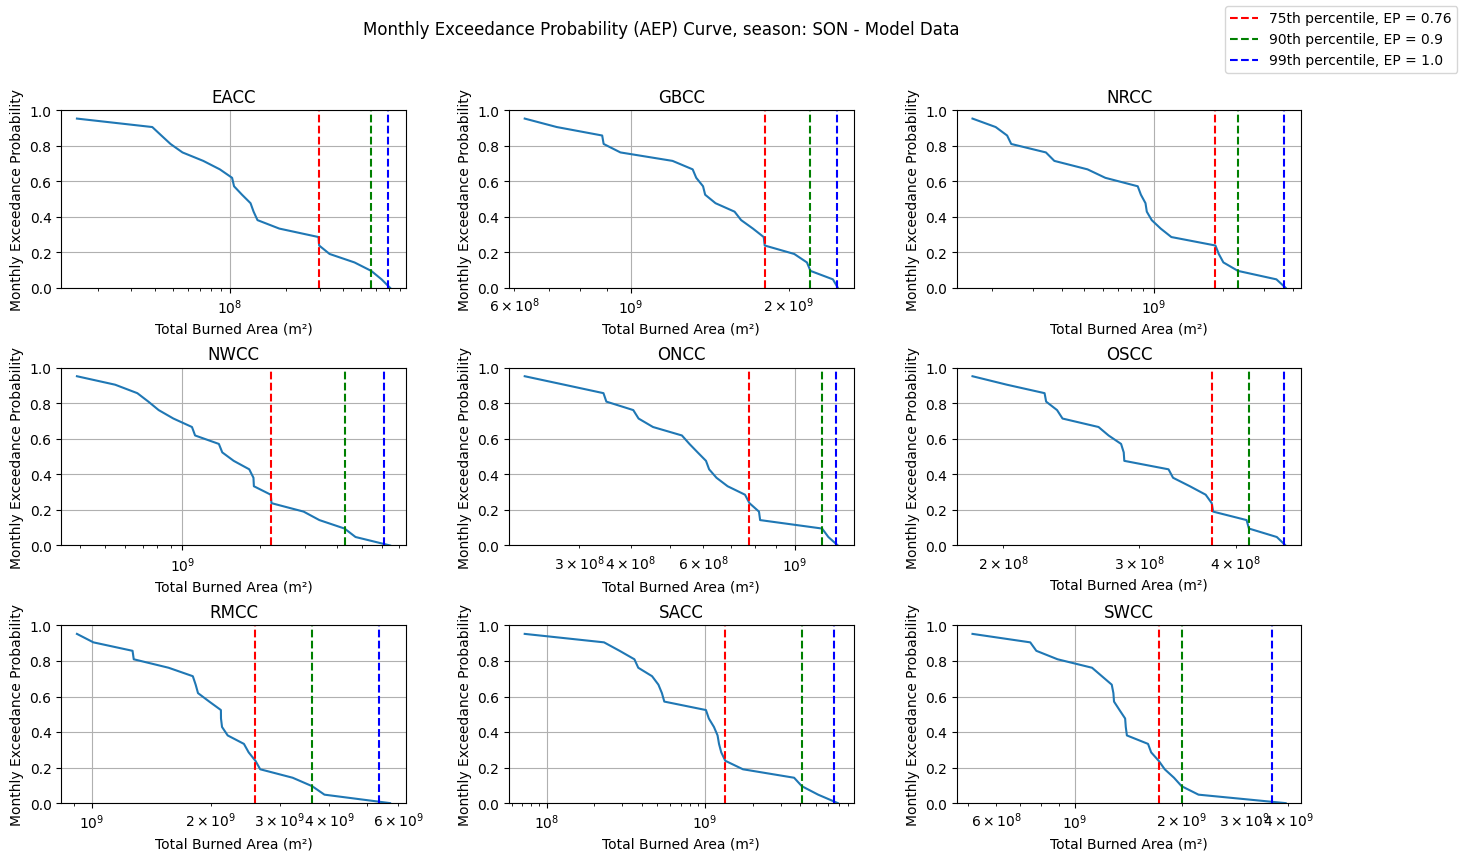

In [ ]:
season = 'SON' # choose the season for which AEP will be constructed (year, DJF, MAM, JJA, SON)

fig = plt.figure(figsize=(16, 9))
fig.suptitle(f'Monthly Exceedance Probability (AEP) Curve, season: {season} - Model Data')

gs = GridSpec(nrows=3, ncols=3, width_ratios=[1, 1, 1], wspace=0.3, hspace=0.45)

for i, reg in enumerate(range(1, 10)):
  BA_df_reg = get_aep(model_US_regions.isel(region=reg), model_var, season)

  quantiles = {}
  for percent in [0.75, 0.90, 0.99]:
    percentile, ep = get_aep_percentile(BA_df_reg, 'spatial_total', percent)
    quantiles[percent] = (percentile, ep)

  row = i // 3
  col = i % 3

  ax = fig.add_subplot(gs[row, col])
  ax.plot(BA_df_reg['spatial_total'], BA_df_reg['ex_prob'])
  ax.set_xlabel('Total Burned Area (m²)')
  ax.set_ylabel('Monthly Exceedance Probability')
  ax.set_title(f'{region_id_to_name[reg]}')
  line_75 = ax.axvline(x=quantiles[0.75][0], color='r', linestyle='--', label=f'75th percentile, EP = {quantiles[0.75][1]}')
  line_90 = ax.axvline(x=quantiles[0.90][0], color='g', linestyle='--', label=f'90th percentile, EP = {quantiles[0.90][1]}')
  line_99 = ax.axvline(x=quantiles[0.99][0], color='b', linestyle='--', label=f'99th percentile, EP = {quantiles[0.99][1]}')
  ax.set_ylim(0, 1)
  ax.grid(True)
  ax.set_xscale('log')

plt.figlegend(handles=[line_75, line_90, line_99])
plt.savefig(f'{output_path}/monthly_aep_regions_model.tiff')

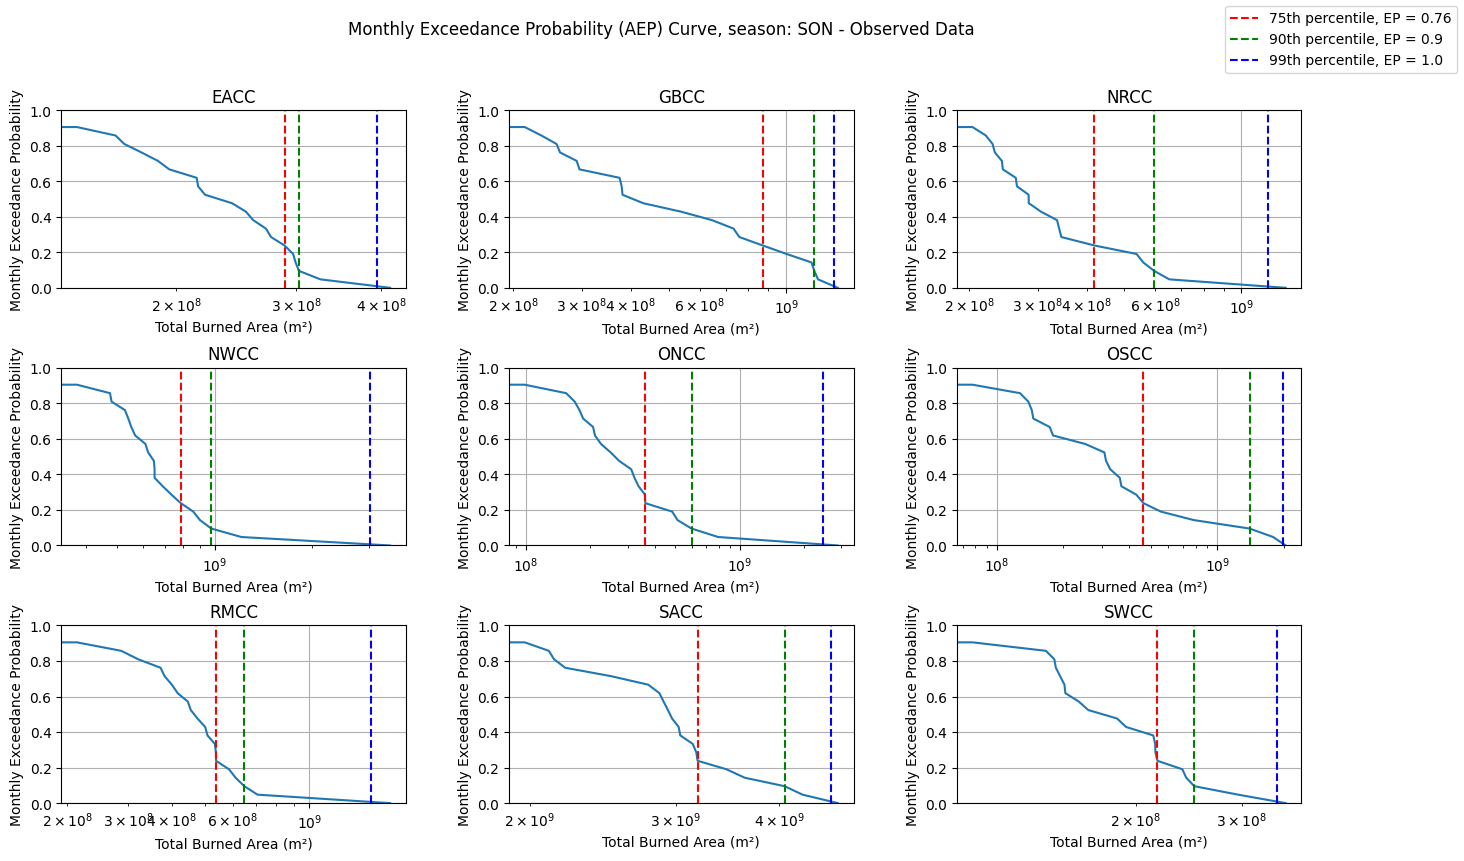

In [ ]:
season = 'SON' # choose the season for which AEP will be constructed (year, DJF, MAM, JJA, SON)

fig = plt.figure(figsize=(16, 9))
fig.suptitle(f'Monthly Exceedance Probability (AEP) Curve, season: {season} - Observed Data')

gs = GridSpec(
    nrows=3,
    ncols=3,
    width_ratios=[1, 1, 1],
    wspace=0.3,
    hspace=0.45)

for i, reg in enumerate(range(1, 10)):
  BA_df_reg = get_aep(observed_US_regions.isel(region=reg), observed_var, season)

  quantiles = {}
  for percent in [0.75, 0.90, 0.99]:
    percentile, ep = get_aep_percentile(BA_df_reg, 'spatial_total', percent)
    quantiles[percent] = (percentile, ep)

  row = i // 3
  col = i % 3

  ax = fig.add_subplot(gs[row, col])
  ax.plot(BA_df_reg['spatial_total'], BA_df_reg['ex_prob'])
  ax.set_xlabel('Total Burned Area (m²)')
  ax.set_ylabel('Monthly Exceedance Probability')
  ax.set_title(f'{region_id_to_name[reg]}')
  line_75 = ax.axvline(x=quantiles[0.75][0], color='r', linestyle='--', label=f'75th percentile, EP = {quantiles[0.75][1]}')
  line_90 = ax.axvline(x=quantiles[0.90][0], color='g', linestyle='--', label=f'90th percentile, EP = {quantiles[0.90][1]}')
  line_99 = ax.axvline(x=quantiles[0.99][0], color='b', linestyle='--', label=f'99th percentile, EP = {quantiles[0.99][1]}')
  ax.set_ylim(0, 1)
  ax.grid(True)
  ax.set_xscale('log')

plt.figlegend(handles=[line_75, line_90, line_99])
plt.savefig(f'{output_path}/monthly_aep_regions_observed.tiff')

What is the probability of exceeding X sq m of montly aggregate BA in the next 5 years?

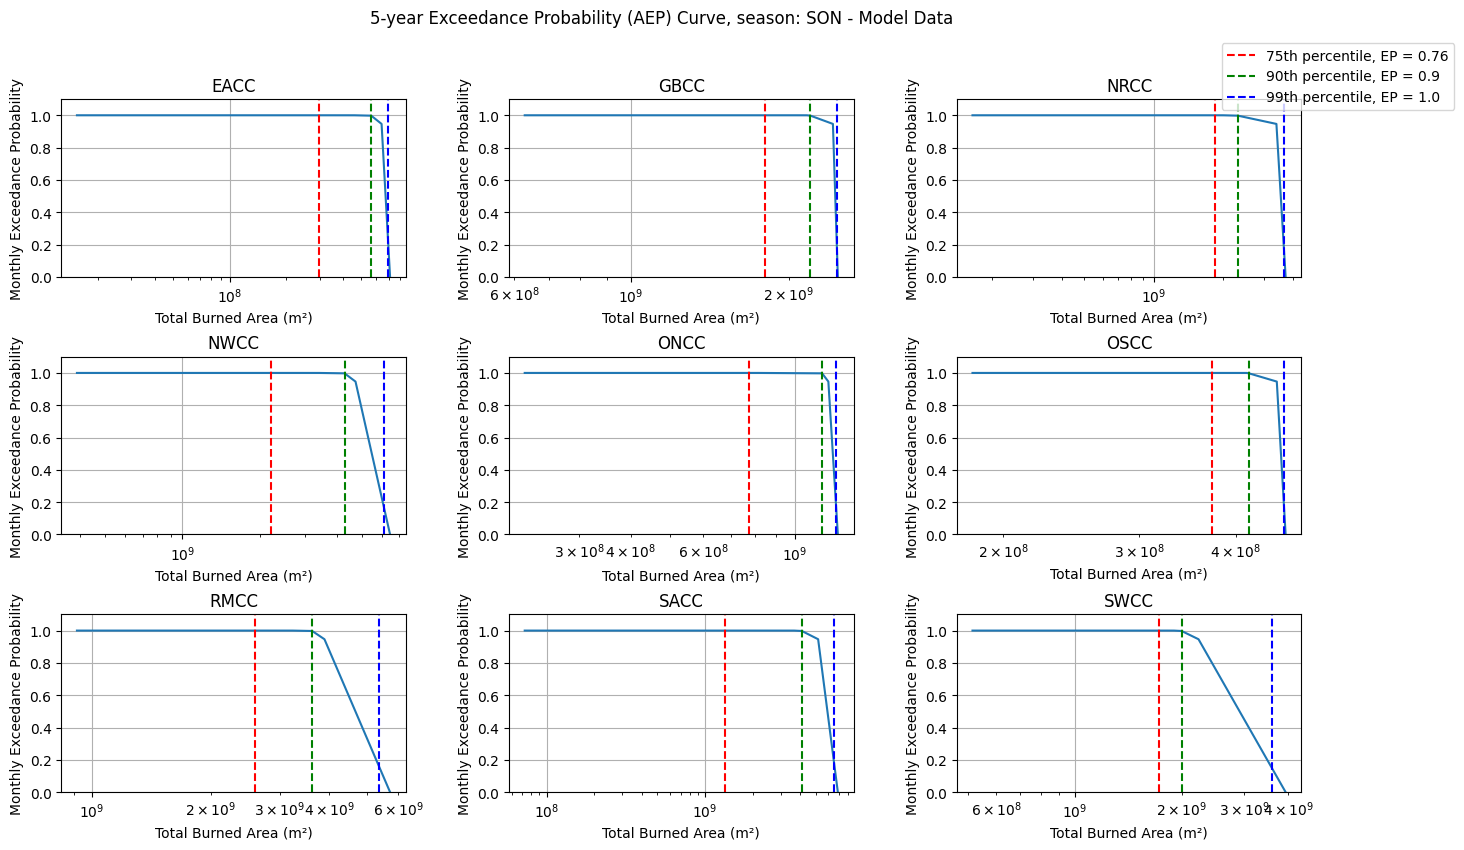

In [ ]:
season = 'SON' # choose the season for which AEP will be constructed (year, DJF, MAM, JJA, SON)

fig = plt.figure(figsize=(16, 9))
fig.suptitle(f'5-year Exceedance Probability (AEP) Curve, season: {season} - Model Data')

gs = GridSpec(
    nrows=3,
    ncols=3,
    width_ratios=[1, 1, 1],
    wspace=0.3,
    hspace=0.45)

n_months = 12*5

# Variables to store the handles and labels from the last iteration for the figure legend
final_handles = []
final_labels = []

for i, reg in enumerate(range(1, 10)): # i is an integer index here
  BA_df_reg = get_aep(model_US_regions.isel(region=reg), model_var, season)
  BA_df_reg['percentile'] = BA_df_reg['spatial_total'].rank(pct=True)

  # Rename the inner loop variable to avoid shadowing 'i'
  P_period_values = []
  for ex_prob_val in BA_df_reg['ex_prob']: # ex_prob_val is a float
    P = 1-(1-ex_prob_val)**n_months
    P_period_values.append(P)
  BA_df_reg['P_period'] = P_period_values

  quantiles = {}
  for percent in [0.75, 0.90, 0.99]:
    percentile, ep = get_aep_percentile(BA_df_reg, 'spatial_total', percent)
    quantiles[percent] = (percentile, ep)

  row = i // 3 # i is still an integer here
  col = i % 3  # i is still an integer here

  ax = fig.add_subplot(gs[row, col])
  ax.plot(BA_df_reg['spatial_total'], BA_df_reg['P_period'])
  ax.set_xlabel('Total Burned Area (m²)')
  ax.set_ylabel('Monthly Exceedance Probability')
  ax.set_title(f'{region_id_to_name[reg]}')
  line_75 = ax.axvline(x=quantiles[0.75][0], color='r', linestyle='--', label=f'75th percentile, EP = {quantiles[0.75][1]}')
  line_90 = ax.axvline(x=quantiles[0.90][0], color='g', linestyle='--', label=f'90th percentile, EP = {quantiles[0.90][1]}')
  line_99 = ax.axvline(x=quantiles[0.99][0], color='b', linestyle='--', label=f'99th percentile, EP = {quantiles[0.99][1]}')
  ax.set_ylim(0, 1.1)
  ax.grid(True)
  ax.set_xscale('log')

  # Collect handles and labels from the last iteration for the figure legend
  if i == 8: # Assuming region 9 is the last one (0-indexed loop for 1-10 regions)
      final_handles = [line_75, line_90, line_99]
      final_labels = [h.get_label() for h in final_handles]

# Create a single legend for the entire figure using the collected handles and labels
fig.legend(handles=final_handles, labels=final_labels, loc='upper right', bbox_to_anchor=(1.0, 0.95))
plt.savefig(f'{output_path}/5year_aep_regions_model.tiff')

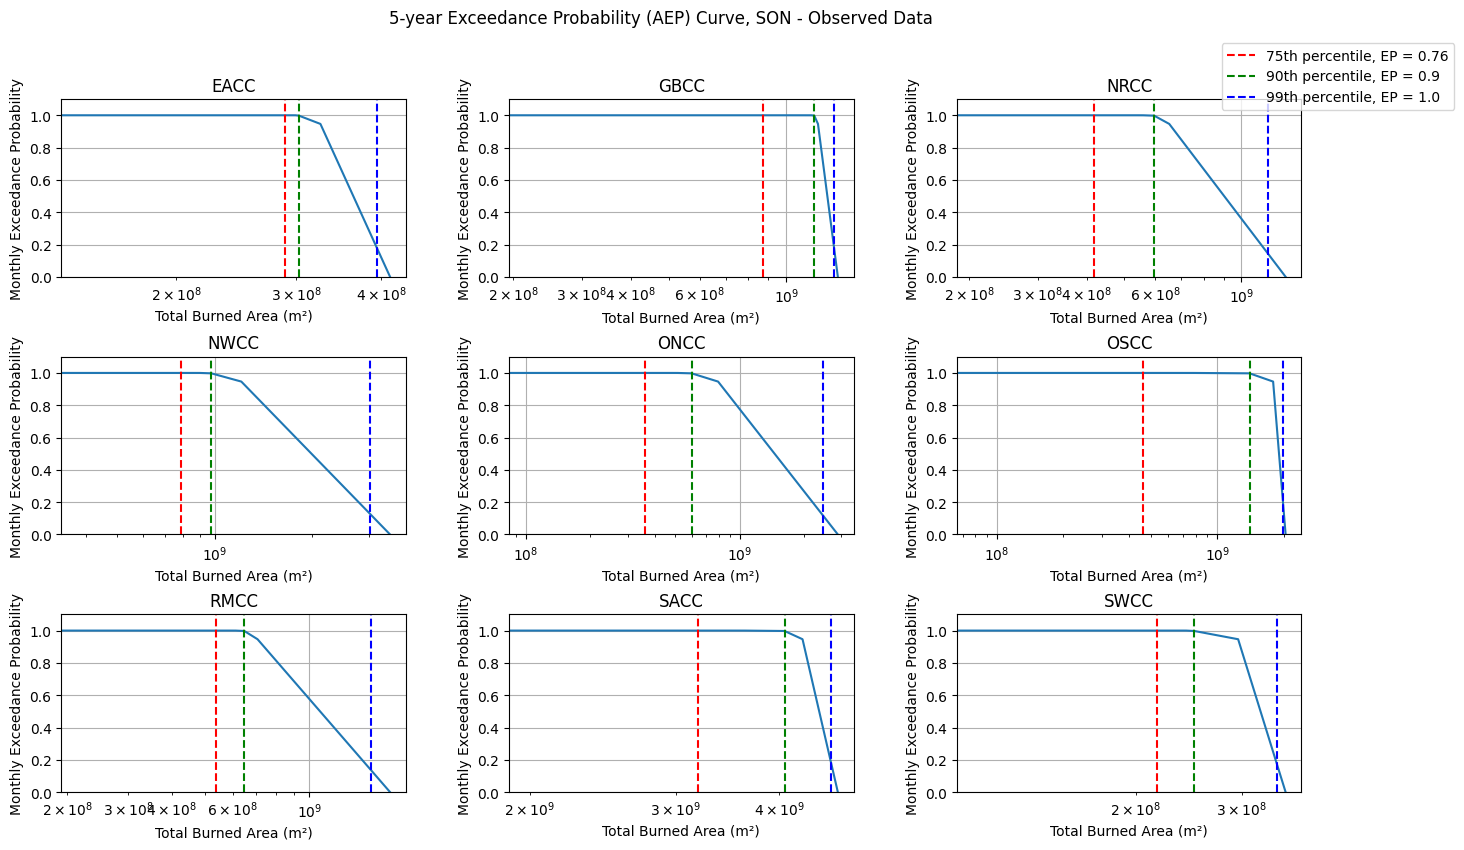

In [ ]:
season = 'SON' # choose the season for which AEP will be constructed (year, DJF, MAM, JJA, SON)

fig = plt.figure(figsize=(16, 9))
fig.suptitle(f'5-year Exceedance Probability (AEP) Curve, {season} - Observed Data')

gs = GridSpec(
    nrows=3,
    ncols=3,
    width_ratios=[1, 1, 1],
    wspace=0.3,
    hspace=0.45)

n_months = 12*5

# Variables to store the handles and labels from the last iteration for the figure legend
final_handles = []
final_labels = []

for i, reg in enumerate(range(1, 10)): # i is an integer index here
  BA_df_reg = get_aep(observed_US_regions.isel(region=reg), observed_var, season)
  BA_df_reg['percentile'] = BA_df_reg['spatial_total'].rank(pct=True)

  # Rename the inner loop variable to avoid shadowing 'i'
  P_period_values = []
  for ex_prob_val in BA_df_reg['ex_prob']: # ex_prob_val is a float
    P = 1-(1-ex_prob_val)**n_months
    P_period_values.append(P)
  BA_df_reg['P_period'] = P_period_values

  quantiles = {}
  for percent in [0.75, 0.90, 0.99]:
    percentile, ep = get_aep_percentile(BA_df_reg, 'spatial_total', percent)
    quantiles[percent] = (percentile, ep)

  row = i // 3 # i is still an integer here
  col = i % 3  # i is still an integer here

  ax = fig.add_subplot(gs[row, col])
  ax.plot(BA_df_reg['spatial_total'], BA_df_reg['P_period'])
  ax.set_xlabel('Total Burned Area (m²)')
  ax.set_ylabel('Monthly Exceedance Probability')
  ax.set_title(f'{region_id_to_name[reg]}')
  line_75 = ax.axvline(x=quantiles[0.75][0], color='r', linestyle='--', label=f'75th percentile, EP = {quantiles[0.75][1]}')
  line_90 = ax.axvline(x=quantiles[0.90][0], color='g', linestyle='--', label=f'90th percentile, EP = {quantiles[0.90][1]}')
  line_99 = ax.axvline(x=quantiles[0.99][0], color='b', linestyle='--', label=f'99th percentile, EP = {quantiles[0.99][1]}')
  ax.set_ylim(0, 1.1)
  ax.grid(True)
  ax.set_xscale('log')

  # Collect handles and labels from the last iteration for the figure legend
  if i == 8: # Assuming region 9 is the last one (0-indexed loop for 1-10 regions)
      final_handles = [line_75, line_90, line_99]
      final_labels = [h.get_label() for h in final_handles]

# Create a single legend for the entire figure using the collected handles and labels
fig.legend(handles=final_handles, labels=final_labels, loc='upper right', bbox_to_anchor=(1.0, 0.95))
plt.savefig(f'{output_path}/5year_aep_regions_observed.tiff')